# Prepare

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from copy import deepcopy

import experiments as meas
from slab import AttrDict
from experiments import MultimodeStation, CharacterizationRunner, SweepRunner

from job_server import JobClient
from job_server.database import get_database
from job_server.config_versioning import ConfigVersionManager
from experiments.MM_dual_rail_base import MM_dual_rail_base


active_reset_dict = {
    'active_reset': True, # on recalibration of readout, turn off active reset because it will be wrong for selecting when to apply the qubit pulse
    'ef_reset': True,
    'storage_reset': False,
    'coupler_reset': False,
    'pre_selection_reset': True,
    'man_reset': False, 
    'use_qubit_man_reset': True, # whether to use the qubit
    'pre_selection_parity':False,
}
update_main = True 

Importing all classes from  C:\python\multimode_expts\experiments\dual_rail
Importing all classes from  C:\python\multimode_expts\experiments\qsim
Importing all classes from  C:\python\multimode_expts\experiments\qubit_cavity
Importing all classes from  C:\python\multimode_expts\experiments\single_qubit
Importing all classes from  C:\python\multimode_expts\experiments\transduction
Skipped top-level files ['branch_manager.py', 'characterization_runner.py', 'dataset.py', 'MM_base.py', 'MM_dual_rail_base.py', 'MM_rb_base.py', 'mock_hardware.py', 'sequential_experiment.py', 'sequential_experiment_classes.py', 'station.py', 'sweep_runner.py']


In [3]:
# Initialize database and config manager
db = get_database()
from pathlib import Path; config_dir = str(Path.cwd().parent.parent / 'configs')
config_manager = ConfigVersionManager(config_dir)

# Initialize job client (handle submitting and waiting for jobs)
client = JobClient()

# Check server health
health = client.health_check()
client.print_queue()


=== Job Queue ===

No job currently running

Pending: 0 jobs



In [4]:
# Who is running these experiments??
user = 'seb'
print(f"Welcome {user}!")

Welcome seb!


In [5]:
# Initialize station to retrieve soc and configs
# station = MultimodeStation(
#     user = user,
#     experiment_name = "260420_T2_AC_stark",
# )

station = MultimodeStation(
    user=user,
    experiment_name="260526_Transduction",
    project="Transduction",
    log_measurements=True,
    # hardware_config='CFG-HW-20260427-00060',   # YAML hardware config
    # storage_man_file='CFG-M1-20260427-00019',  # CSV storage-man swap
)


mm_base_calib = MM_dual_rail_base(station.hardware_cfg, station.soccfg)

[STATION] Using main hardware_config version: CFG-HW-20260708-00159
[STATION] Using main multiphoton_config version: CFG-MP-20260121-00001
[STATION] Using main man1_storage_swap version: CFG-M1-20260708-00013
[STATION] Using main floquet_storage_swap version: CFG-FL-20260624-00043
[STATION] Lab-notebook vault: G:\Shared drives\SLab\Multimode
Data, plots, logs will be stored in: C:\experiments\260526_Transduction
Hardware configs will be read from C:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260708-00159.yml
dict_keys(['Pyro.NameServer', 'Qick101'])
QICK running on ZCU216, software version 0.2.291

Firmware configuration (built Tue Oct 15 12:06:51 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	7 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 32768 samples (5.128 us)
		fs=6389.760 MHz, fabric=399.360 MHz, 32-bit DDS, range=6389.760 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 32768

## Experiments to run

Depending on stage of cooldown, we will run a different sequence of calibration experiments. For example, amplitude rabi don't need to be updated every time, but the frequency correction from T2 is important to do every day. In the dictionary experiments to run, we will speciy the experiments we want to run. 

In [6]:
expts_to_run = {# readout 
                'res_spec': True, # Readout spectroscopy
                'single_shot': True, 
                # qubit ge 
                'pulse_probe_ge': True,
                't2_ge': True, 
                'amplitude_ge': True,
                't1_ge': True,
                # qubit ef
                'pulse_probe_ef': True,
                't2_ef': True,
                'amplitude_ef': True,
                't1_ef': True,

                # manipulate 
                'man_modes': [1], # [1,2] if also want to run mode 2
                'pulse_probe_f0g1': True,
                'length_rabi_sweep':True,
                'length_rabi':False, # this will run automatically if the length_rabi_sweep is set to True
                'chi_ge': True, 
                'chi_ef': True,
                'RB': False,

                #storage
                'stor_modes': [1,2,3,4,5,6,7], # [1,2, .., 7] if also want to run  all modes 
                'stor_modes': [1,2,3,4,6,7], # [1,2, .., 7] if also want to run  all modes 
                # 'stor_modes': [3, 4, 5], # [1,2, .., 7] if also want to run  all modes 
                'stor_spectroscopy': True,
                'sideband_freq_sweep': True,
                'sideband_length_rabi': True,
                # 'storage_t1': True
                }

# Qubit characterization

## Update main configs

In [ ]:
# When ready uncomment:
# station.update_all_station_snapshots(update_main=True)

In [ ]:
# station.hardware_cfg.hw.yoko_coupler.current = 0.00035
# station.hardware_cfg.hw.yoko_coupler.current

0.00035

## Resonator spectroscopy

Fitting parameters are wrong because of using the hanger function (more or less reflection/2), instead of transmission. Is this an easy fix?

In [ ]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
resspec_defaults = AttrDict(dict(
    # start = center - span / 2, 
    # step = span / expts, # min step ~1 Hz
    # center and span can be user supplied or use defaults in preproc
    expts = 250, # Number experiments stepping from start
    reps = 500, # Number averages per point
    relax_delay = 50, # us
    pulse_e = False, # add ge pi pulse prior to measurement
    pulse_f = False, # add ef pi pulse prior to measurement
    pulse_cavity = False,  # prepulse on cavity prior to measurement (False also disables next line)
    cavity_pulse = [4984.373226159381, 800, 2, 0], # [frequency, gain, length, phase]  const pulse
    qubit = 0,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def resspec_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)

    span = kwargs.pop('span', 1.5)  # MHz
    center = kwargs.pop('center', station.hardware_cfg.device.readout.frequency[0])
    expts = kwargs.get('expts', default_expt_cfg.expts)

    expt_cfg.start = center - span / 2
    expt_cfg.step = span / expts
    expt_cfg.update(kwargs)
    station.snapshot_hardware_config(update_main=False)
    return expt_cfg

def resspec_postproc(station, expt):
    old_freq = station.hardware_cfg.device.readout.frequency[0]
    station.hardware_cfg.device.readout.frequency = [expt.data['fit'][0]]
    print(f'Updated readout frequency from {old_freq} to {expt.data["fit"][0]}!')


In [ ]:
# Execute
# =================================
rspec_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.ResonatorSpectroscopyExperiment,
    default_expt_cfg = resspec_defaults,
    preprocessor = resspec_preproc,
    postprocessor = None, # resspec_postproc, # uncomment if you want to update the readout freq from this expt
    job_client=client,
)

if expts_to_run['res_spec']:
    rspec = rspec_runner.execute()
    # rspec.display()

In [ ]:
station.preview_config_update()

## Single Shot

In [13]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
singleshot_defaults = AttrDict(dict(    
    reps=5000,
    relax_delay=500,
    check_f=False,
    active_reset=False,
    man_reset=False,
    storage_reset=False,
    qubit=0,
    pulse_manipulate=False,
    cavity_freq=4984.373226159381,
    cavity_gain=400,
    cavity_length=2,
    prepulse=False,
    pre_sweep_pulse=None,
    gate_based=True,
    qubits=[0],
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def singleshot_postproc(station, expt):
    expt.analyze(plot=False, station=station, subdir=station.autocalib_path)
    fids = expt.data['fids']
    confusion_matrix = expt.data['confusion_matrix']
    thresholds_new = expt.data['thresholds']
    angle = expt.data['angle']
    print(fids)

    hardware_cfg = station.hardware_cfg
    hardware_cfg.device.readout.phase = [hardware_cfg.device.readout.phase[0] + angle]
    hardware_cfg.device.readout.threshold = thresholds_new
    hardware_cfg.device.readout.threshold_list = [thresholds_new]
    hardware_cfg.device.readout.Ie = [np.median(expt.data['Ie_rot'])]
    hardware_cfg.device.readout.Ig = [np.median(expt.data['Ig_rot'])]
    if expt.cfg.expt.active_reset:
        hardware_cfg.device.readout.confusion_matrix_with_active_reset = confusion_matrix
    else:
        hardware_cfg.device.readout.confusion_matrix_without_reset = confusion_matrix
    print('Updated readout!')

Job submitted: JOB-20260708-00316 (queue position: 1)

[0.0s] Job JOB-20260708-00316: pending

[2.0s] Job JOB-20260708-00316: running
[WORKER] Loading HistogramExperiment from experiments.single_qubit.single_shot
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260708-00316_HistogramExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.35mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 66%|████████████████████████▏            | 3276/5000 [00:08<00:04, 399.42it/s]
[32.2s] Job JOB-20260708-00316: completed
100%|█████████████████████████████████████| 5000/5000 [00:12<00:00, 399.74it/s]
Unrotated:
Ig -72.11216216216215 +/- 28.65416335397009 	 Qg -22.267567567567568 +/- 26.496537212940577 	 Amp g 75.47190534946203
Ie 7.175675675675675 +/- 29.56726111068806 	 Qe -21.872972972972974 +/- 26.223674572815625 	 Amp e 23.01993197381108
Rotated:
Ig -72.24178522668421 +/- 28.655519107932523 	 Qg -21.94179325236477 +/- 26.4

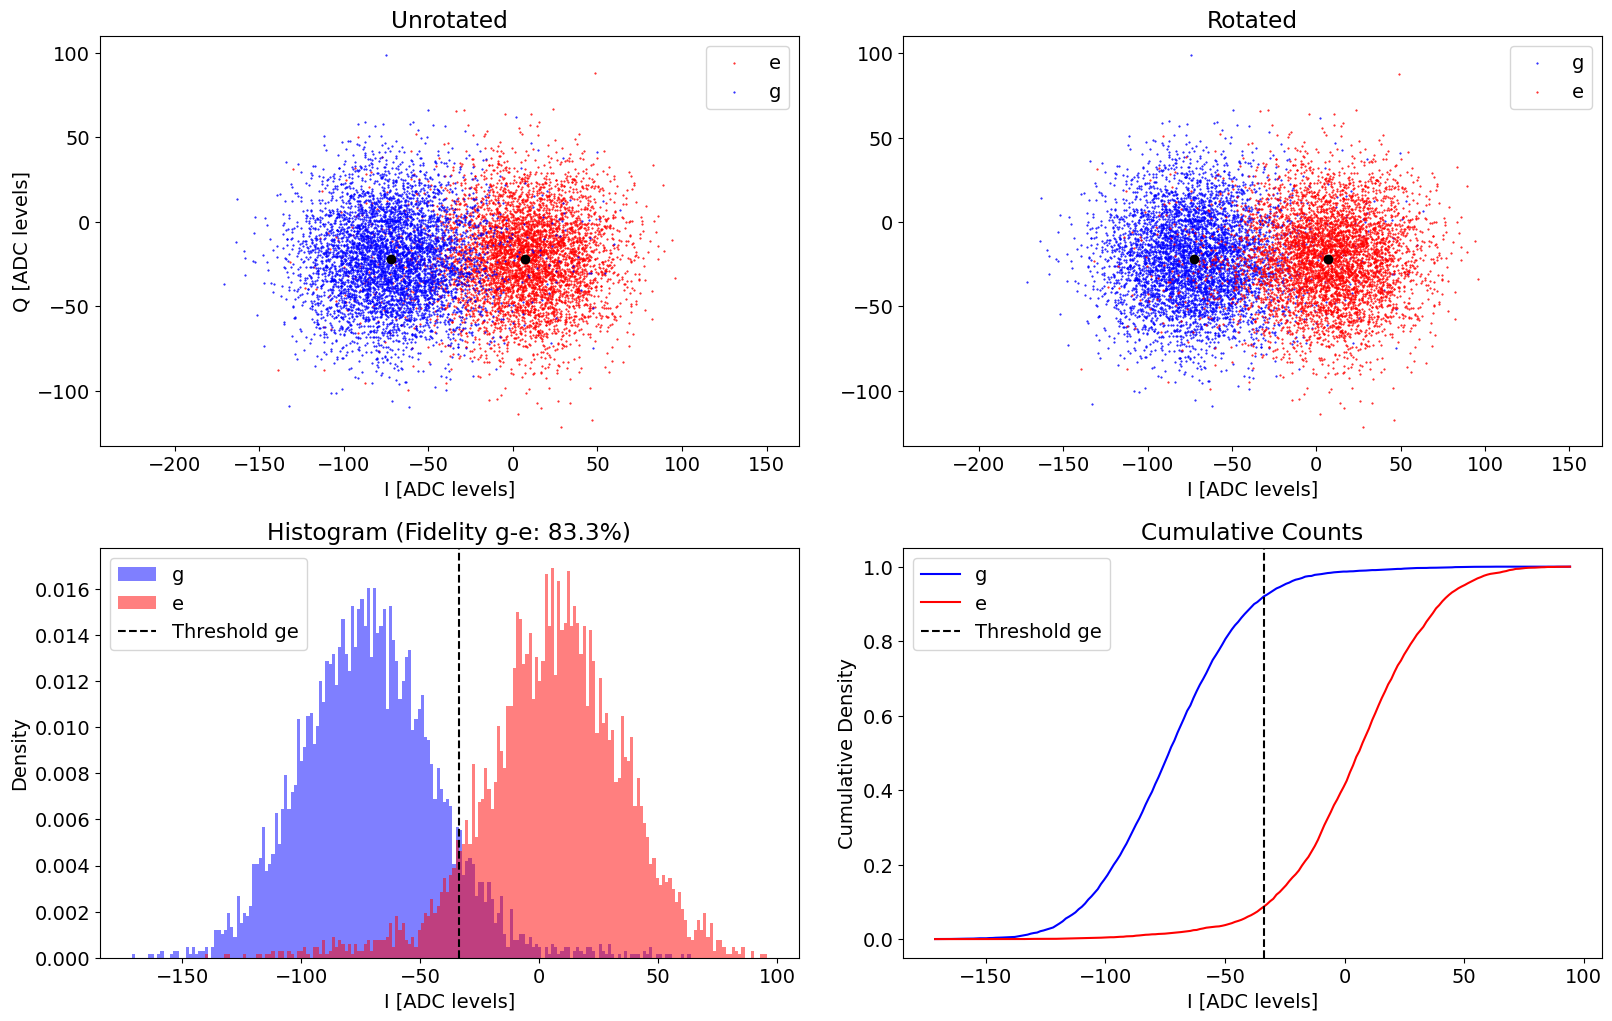

Unrotated:
Ig -72.11216216216215 +/- 28.65416335397009 	 Qg -22.267567567567568 +/- 26.496537212940577 	 Amp g 75.47190534946203
Ie 7.175675675675675 +/- 29.56726111068806 	 Qe -21.872972972972974 +/- 26.223674572815625 	 Amp e 23.01993197381108
Rotated:
Ig -72.24178522668421 +/- 28.655519107932523 	 Qg -21.94179325236477 +/- 26.495070984008738 	 Amp g 75.50044916335195
Ie 7.033271262218063 +/- 29.56929158759711 	 Qe -21.901818409979054 +/- 26.221385026275833 	 Amp e 23.003403102837627


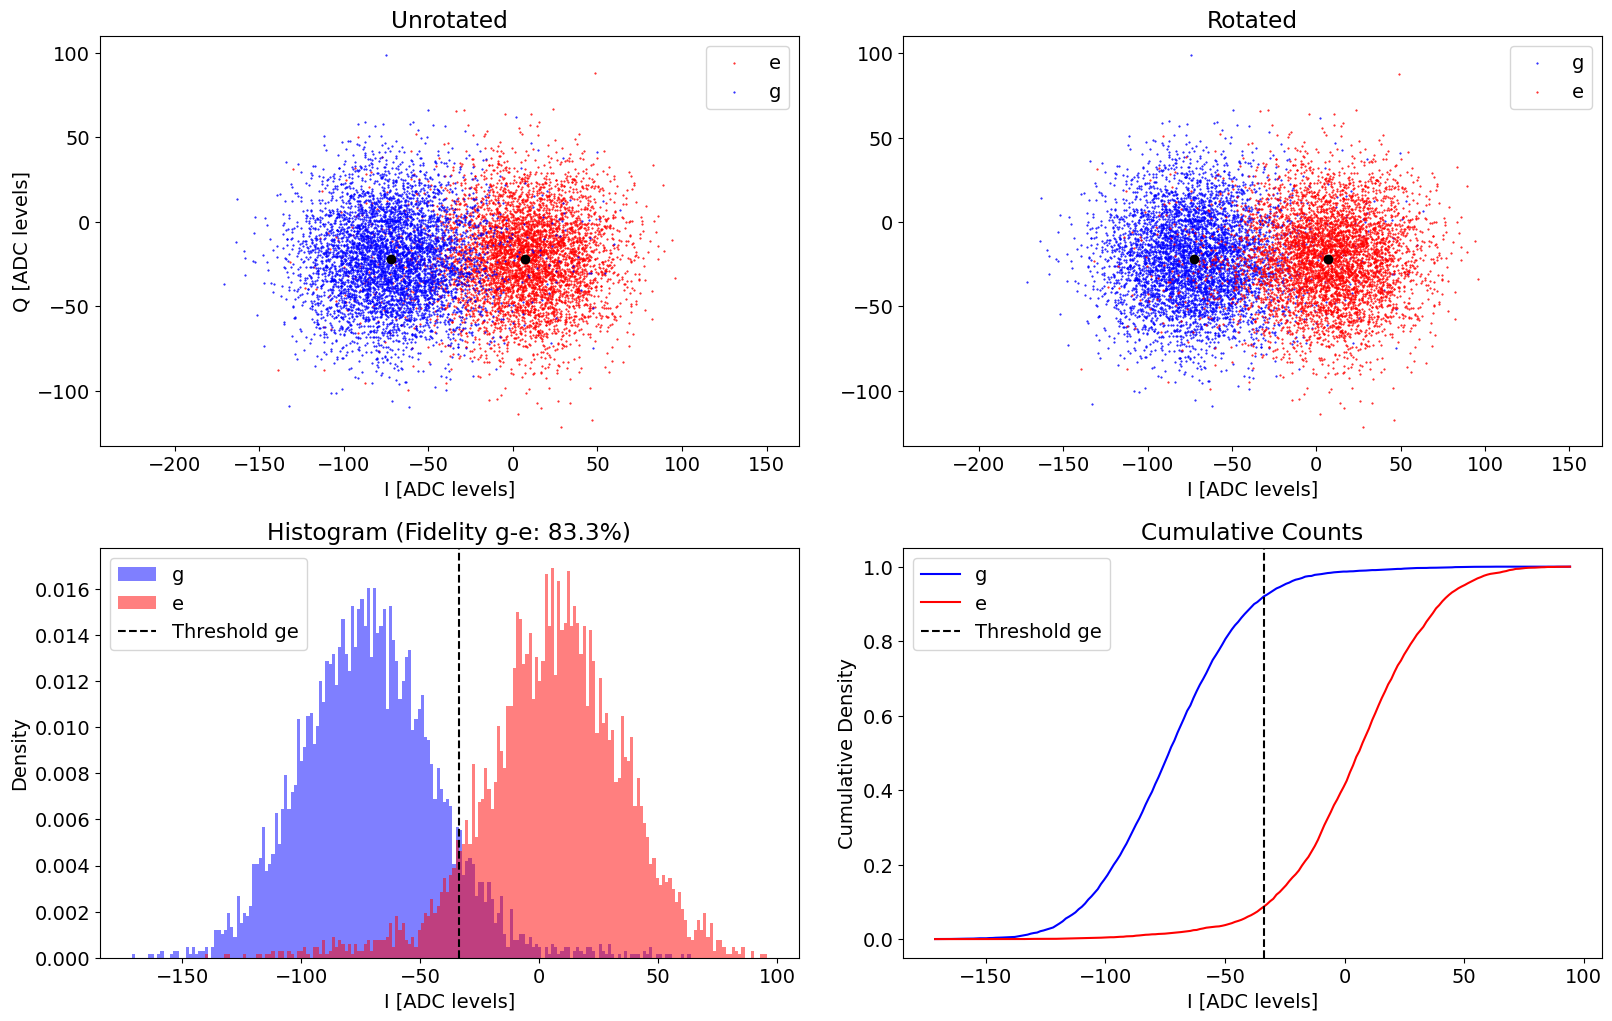

ge fidelity (%): 83.29999999999997
rotation angle (deg): -0.2851435838381897
threshold ge: -33.81887690085932


In [14]:
# Execute
# =================================
ss_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.HistogramExperiment,
    default_expt_cfg = singleshot_defaults,
    postprocessor = singleshot_postproc,
    job_client=client,
)

if expts_to_run['single_shot']:
    ss = ss_runner.execute(
        go_kwargs=dict(analyze=False, display=False),
        check_f=False,
        relax_delay=2500,
        reps=5000,
        # **active_reset_dict
    )
    ss.display(station)

In [16]:
station.snapshot_hardware_config(update_main=update_main)
# station.preview_config_update()

[CONFIG] Reusing existing hardware_config version CFG-HW-20260708-00140
[CONFIG] Updated main hardware_config to CFG-HW-20260708-00140


'CFG-HW-20260708-00140'

## Qubit ge

### Pulse-probe

In [ ]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
gespec_defaults = AttrDict(dict(    
    # start=center-span/2,  # [MHz]
    # step=span/expts,  # min step ~1 MHz
    expts=200,  # Number of experiments stepping from start
    reps=100,  # Number of averages per point
    rounds=1,  # Number of start to finish sweeps to average over
    length=1,  # Qubit probe constant pulse length [us]
    gain=100,  # Qubit pulse gain
    sigma=0.1,  # Qubit flat top sigma
    qubit=[0],
    qubits=[0],
    prepulse=False,
    pre_sweep_pulse=[],
    gate_based=False,
    relax_delay=250,  # Wait time between experiments [us]
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values


def gespec_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)

    span = kwargs.pop('span', 20)  # MHz
    center = kwargs.pop('center', station.hardware_cfg.device.qubit.f_ge[0])
    expts = kwargs.pop('expts', default_expt_cfg.expts)

    expt_cfg.start = center - span / 2
    expt_cfg.step = span / expts

    expt_cfg.span = span
    expt_cfg.center = center
    expt_cfg.expts = expts

    expt_cfg.update(kwargs)
    return expt_cfg

def gespec_postproc(station, expt):
    old_freq = station.hardware_cfg.device.qubit.f_ge[0]
    station.hardware_cfg.device.qubit.f_ge = [expt.data['fit_avgi'][2]]
    print(f'Updated qubit frequency from {old_freq} to {station.hardware_cfg.device.qubit.f_ge[0]}!')
    station.snapshot_hardware_config(update_main=False)

In [ ]:
# Execute
# =================================
gespec_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.PulseProbeSpectroscopyExperiment,
    default_expt_cfg = gespec_defaults,
    preprocessor = gespec_preproc,
    postprocessor = gespec_postproc,
    job_client=client,
)

if expts_to_run['pulse_probe_ge']:
    gespec = gespec_runner.execute(
        span=100, 
        expts=1000, 
        reps=200,
    )
    # gespec.display()

In [ ]:
station.preview_config_update()
# station.snapshot_hardware_config(update_main=True)

### T2 Ramsey

In [10]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
# from sqlalchemy import false


geramsey_defaults = AttrDict(dict(
    ramsey_freq=0.2,  # [MHz]
    start=0.01, # us
    step=0.5,
    expts=101,
    reps=200,
    rounds=1,
    pre_sweep_pulse=None,
    post_sweep_pulse=None,
    if_ef=False,
    ef_init=True, # redundant
    qubits=[0],
    user_defined_freq=[False, 3568.2038290468167, 5304, 0.035],
    f0g1_cavity=0,
    normalize=False,
    active_reset=False,
    man_reset=False,
    storage_reset=False,
    prepulse=None,
    postpulse=None,
    pre_active_reset_pulse=False,
    gate_based=False,
    advance_phase=0,
    echoes=[False, 0],
    relax_delay=200
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def geramsey_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    # Copied over but what's all this below????
    # Which ones are actually used? 
    # Can we straighten out all the nested boolean logic???
    checkEF = False
    qubit_ge_init = False
    qubit_ge_after = False
    if expt_cfg.if_ef:
        checkEF = True
        qubit_ge_init = True if expt_cfg.ef_init else False
        qubit_ge_after = True if expt_cfg.ef_init else False
    expt_cfg.checkEF = checkEF
    expt_cfg.qubit_ge_init = qubit_ge_init
    expt_cfg.qubit_ge_after = qubit_ge_after

    expt_cfg.prepulse = False if expt_cfg.pre_sweep_pulse is None else True if expt_cfg.prepulse is None else expt_cfg.prepulse,
    expt_cfg.postpulse = False if expt_cfg.post_sweep_pulse is None else True if expt_cfg.postpulse is None else expt_cfg.postpulse,
    
    return expt_cfg

def geramsey_postproc(station, expt):
    old_freq = station.hardware_cfg.device.qubit.f_ge[0]
    station.hardware_cfg.device.qubit.f_ge = [
        station.hardware_cfg.device.qubit.f_ge[0] + min(expt.data['f_adjust_ramsey_avgi'])
    ]
    print(f'Updated qubit frequency from {old_freq} to {station.hardware_cfg.device.qubit.f_ge[0]}!')
    station.snapshot_hardware_config(update_main=False)

Job submitted: JOB-20260708-00244 (queue position: 2)

[0.0s] Job JOB-20260708-00244: pending

[536.2s] Job JOB-20260708-00244: running
[WORKER] Loading RamseyExperiment from experiments.single_qubit.t2_ramsey
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260708-00244_RamseyExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
fge is  3565.01944794471
fef is  3421.5293274532605
 97%|██████████████████████████████████ | 19656/20200 [00:50<00:01, 378.12it/s]
[590.1s] Job JOB-20260708-00244: completed
100%|███████████████████████████████████| 20200/20200 [00:52<00:00, 385.25it/s]
No echoes in the data
Saving C:\experiments\260526_Transduction\data\JOB-20260708-00244_RamseyExperiment.h5
[h5_safe_data] dropped non-numeric keys: ['fit_envelope_avgi', 'fit_envelope_avgq', 'fit_envelope']
[WORKER] Saving expt object to: C:\experiments\260526_Transduction\expt_objs\J

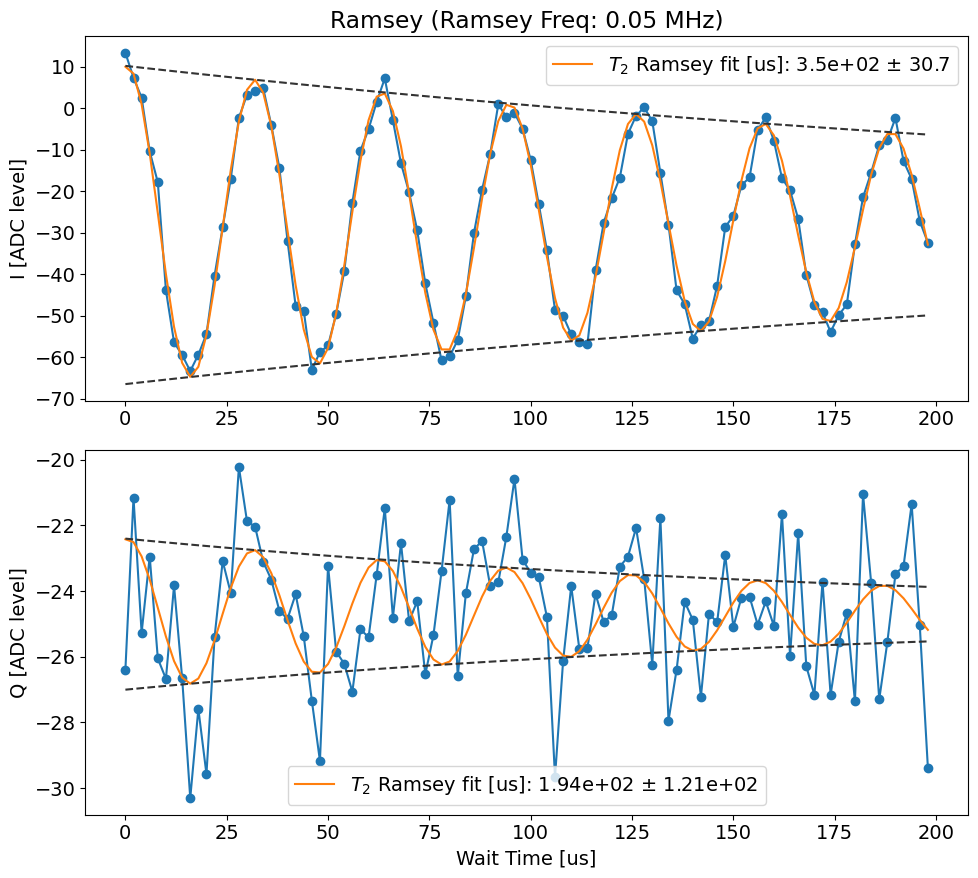

In [11]:
# Execute
# =================================
geramsey_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.RamseyExperiment,
    default_expt_cfg = geramsey_defaults,
    preprocessor = geramsey_preproc,
    postprocessor = geramsey_postproc,
    job_client=client,
)

if expts_to_run['t2_ge']:
    geramsey = geramsey_runner.execute(
        # ramsey_freq = 0.2,
        ramsey_freq = 0.05,
        step=2,
        # step=0.01,
        active_reset=False,
        relax_delay=2500,
        postprocess=True,
        if_ef=False,
        echoes=[False,10]
    )
    # geramsey.display()

In [12]:
station.preview_config_update()
# station.snapshot_hardware_config(update_main=True)

Comparing configurations:
Parent config file: C:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260707-00093.yml
Key 'device.qubit.f_ge' differs:
  Old value (config1): [3565.01944794471]
  New value (config2): [3565.037621441789]
Key 'device.readout.phase' differs:
  Old value (config1): [-39.29939535350027]
  New value (config2): [-38.335632024968334]
Key 'device.readout.threshold' differs:
  Old value (config1): [-29.855175475985362]
  New value (config2): [-32.290190133248956]
Key 'device.readout.threshold_list' differs:
  Old value (config1): [[-29.855175475985362]]
  New value (config2): [[-32.290190133248956]]
Key 'device.readout.confusion_matrix_without_reset' differs:
  Old value (config1): [0.9289999999999999, 0.07100000000000006, 0.10202040408081624, 0.8979795959191837]
  New value (config2): [0.9169999999999998, 0.08300000000000018, 0.08460000000000002, 0.9154]
Key 'device.readout.Ie' differs:
  Old value (config1): [11.278049520112805]
  New value (config

### Amplitude Rabi

We should probably use a cosine fit with fixed phase=0 instead of decaying sine with varying phase?

In [ ]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
amprabi_defaults = AttrDict(dict(
    start=0,
    step=60,
    expts=151,
    reps=200,
    rounds=1,
    sigma_test=None,
    qubit=0,
    pulse_type='gauss',
    drag_beta=0.0,
    pulse_ge_init=False,
    pulse_ge_after=False,
    checkZZ=False,
    checkEF=False,
    qubits=[0],
    flat_length=0,
    normalize=False,
    single_shot=False,
    singleshot_reps=10000,
    span=50,
    user_defined_freq=[False, 3568.203829046816],
    prepulse=False,
    postpulse=False, 
    if_ef=False,  # If true, will check ef frequency and update it
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def amprabi_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    # Copied over but what's all this below????
    # Which ones are actually used? 
    # Can we straighten out all the nested boolean logic???
    pulse_ge = station.hardware_cfg.device.qubit.pulses.pi_ge
    if expt_cfg.sigma_test is None:
        expt_cfg.sigma_test = pulse_ge.sigma[0]
    if expt_cfg.step is None:
        expt_cfg.step = int(pulse_ge.gain[0] / (expt_cfg.expts - 1))
    
    expt_cfg.checkEF = False
    expt_cfg.pulse_ge_init = False
    expt_cfg.pulse_ge_after = False
    if expt_cfg.if_ef:
        expt_cfg.checkEF = True
        expt_cfg.pulse_ge_init = True
        expt_cfg.pulse_ge_after = True
    
    return expt_cfg

def amprabi_postproc(station, expt):
    station.hardware_cfg.device.qubit.pulses.pi_ge.gain = [expt.data['pi_gain_avgi']]
    station.hardware_cfg.device.qubit.pulses.hpi_ge.gain = [expt.data['hpi_gain_avgi']]
    print('Updated qubit ge pi and hpi gaussian gain!')
    station.snapshot_hardware_config(update_main=False)

In [ ]:
# Execute
# =================================
amprabi_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.AmplitudeRabiExperiment,
    default_expt_cfg = amprabi_defaults,
    preprocessor = amprabi_preproc,
    postprocessor = amprabi_postproc,
    job_client=client,
)

if expts_to_run['amplitude_ge']:
    amprabi = amprabi_runner.execute(
        relax_delay=2500,
        postprocess=True,
        step=120,

    )
    # amprabi.display()

    #After amplitude calibration, do another T2 Ramsey to fine tune frequency
    #Added by Jonginn, as a part of practice
    #Please remove if the below code causes any problem.
    t2_ramsey_ge_after_amp = geramsey_runner.execute(
        ramsey_freq = 0.2,
        step = 0.1,
        active_reset = True,
        relax_delay=250,
    )
    # t2_ramsey_ge_after_amp.display()


In [ ]:
station.preview_config_update()
station.snapshot_hardware_config(update_main=update_main)

### T1

In [13]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
t1_ge_defaults = AttrDict(dict(
    start=0,
    step=20,
    expts=100,
    reps=100,
    rounds=1,
    qubit=0,
    qubit_ef=False,
    normalize=False,
    relax_delay=2500,
))

def t1_ge_postproc(station, expt):
    station.hardware_cfg.device.qubit.T1 = [expt.data['fit_avgi'][3]]
    print('Updated qubit T1!')
    station.snapshot_hardware_config(update_main=False)


Job submitted: JOB-20260708-00247 (queue position: 2)

[0.0s] Job JOB-20260708-00247: pending

[232.1s] Job JOB-20260708-00247: running
[WORKER] Loading T1Experiment from experiments.single_qubit.t1
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260708-00247_T1Experiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 98%|███████████████████████████████████▍| 9828/10000 [00:34<00:00, 263.66it/s]
[269.6s] Job JOB-20260708-00247: completed
100%|███████████████████████████████████| 10000/10000 [00:34<00:00, 286.33it/s]
C:\python\multimode_expts\fitting\fitting.py:56: RuntimeWarning: overflow encountered in exp
  return y0 + yscale*np.exp(-(x-x0)/decay)
Saving C:\experiments\260526_Transduction\data\JOB-20260708-00247_T1Experiment.h5
[WORKER] Saving expt object to: C:\experiments\260526_Transduction\expt_objs\JOB-20260708-00247_expt.pkl

Job completed! Data: C:\exper

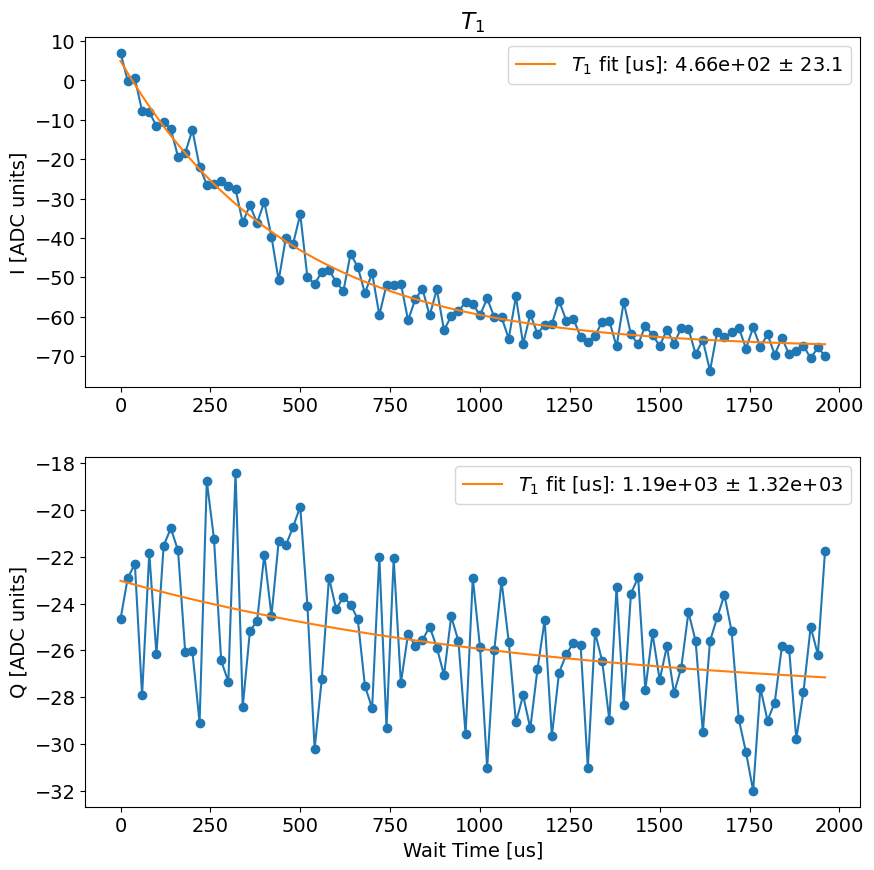

In [14]:
# Execute
# =================================
t1_ge_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.t1.T1Experiment,
    default_expt_cfg=t1_ge_defaults,
    postprocessor=t1_ge_postproc,
    job_client=client,
)

if expts_to_run['t1_ge']:
    t1_ge = t1_ge_runner.execute()
    # t1_ge.display()

In [15]:
# station.preview_config_update()
station.snapshot_hardware_config(update_main=update_main)

[CONFIG] Reusing existing hardware_config version CFG-HW-20260708-00104
[CONFIG] Updated main hardware_config to CFG-HW-20260708-00104


'CFG-HW-20260708-00104'

## Qubit ef

### Pulse-probe

In [ ]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
efspec_defaults = AttrDict(dict(
    start=3415,
    step=0.05,
    expts=500,
    reps=200,
    rounds=1,
    length=1,
    gain=100,
    qubit_f=False,
    qubit=0,
    cavity_drive=False,
    wait_qubit=False,
    relax_delay=500,
))

def efspec_postproc(station, expt):
    old_freq = station.hardware_cfg.device.qubit.f_ef[0]
    station.hardware_cfg.device.qubit.f_ef = [expt.data['fit_avgi'][2]]
    print(f'Updated qubit ef frequency from {old_freq} to {station.hardware_cfg.device.qubit.f_ef[0]}!')
    station.snapshot_hardware_config(update_main=False)

In [ ]:
# Execute
# =================================
efspec_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.PulseProbeEFSpectroscopyExperiment,
    default_expt_cfg=efspec_defaults,
    postprocessor=efspec_postproc,
    job_client=client,
)

if expts_to_run['pulse_probe_ef']:
    qspec_ef = efspec_runner.execute()
    qspec_ef.display()

### T2 Ramsey

In [16]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
# Reuse ge defaults but with if_ef=True
eframsey_defaults = AttrDict(deepcopy(geramsey_defaults))
eframsey_defaults.if_ef = True
eframsey_defaults.ef_init = True
eframsey_defaults.ramsey_freq = 3  # Typical ef ramsey frequency

def eframsey_postproc(station, expt):
    old_freq = station.hardware_cfg.device.qubit.f_ef[0]
    station.hardware_cfg.device.qubit.f_ef = [
        station.hardware_cfg.device.qubit.f_ef[0] + min(expt.data['f_adjust_ramsey_avgi'])
    ]
    print(f'Updated qubit ef frequency from {old_freq} to {station.hardware_cfg.device.qubit.f_ef[0]}!')
    station.snapshot_hardware_config(update_main=False)

Job submitted: JOB-20260708-00250 (queue position: 2)

[0.0s] Job JOB-20260708-00250: pending

[534.6s] Job JOB-20260708-00250: running
[WORKER] Loading RamseyExperiment from experiments.single_qubit.t2_ramsey
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260708-00250_RamseyExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
fge is  3565.037621441789
fef is  3421.5293274532605
 95%|█████████████████████████████████  | 19110/20200 [00:48<00:02, 392.19it/s]
[589.0s] Job JOB-20260708-00250: completed
100%|███████████████████████████████████| 20200/20200 [00:51<00:00, 395.14it/s]
No echoes in the data
Saving C:\experiments\260526_Transduction\data\JOB-20260708-00250_RamseyExperiment.h5
[h5_safe_data] dropped non-numeric keys: ['fit_envelope_avgi', 'fit_envelope_avgq', 'fit_envelope']
[WORKER] Saving expt object to: C:\experiments\260526_Transduction\expt_objs\

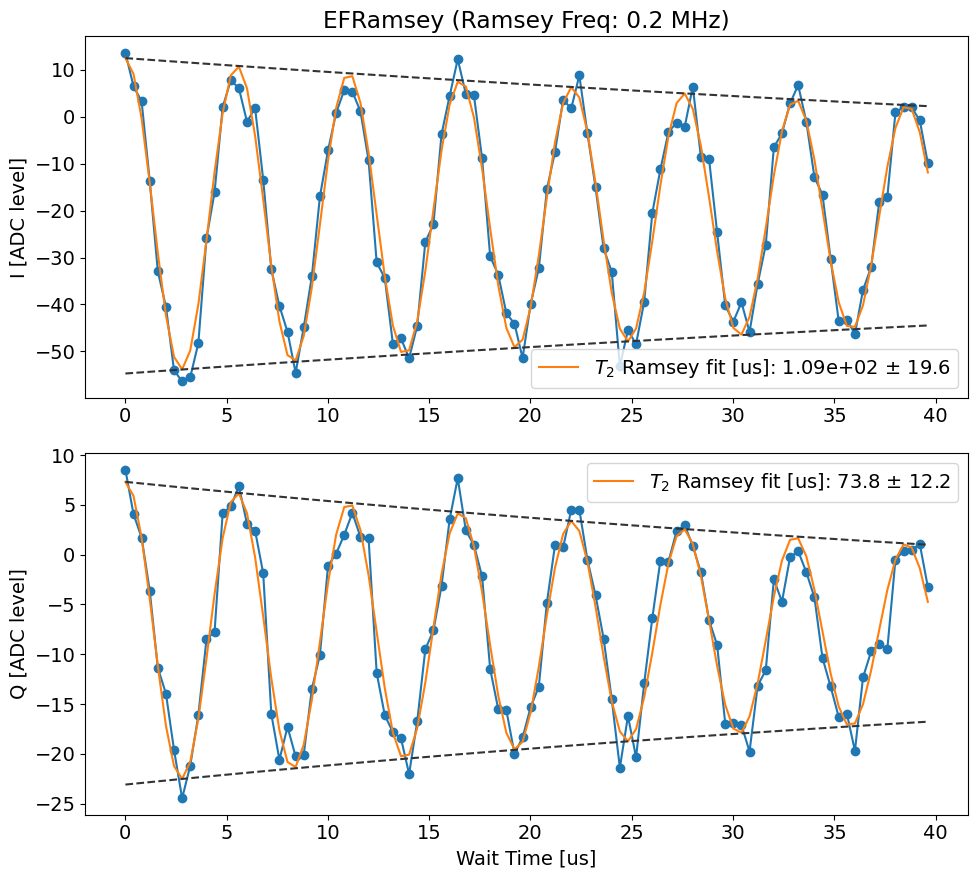

Current pi pulse frequency: 3421.5293274532605
Fit frequency from I [MHz]: 0.181496316246917 +/- 0.00026385816363626226
Suggested new pi pulse frequency from fit I [MHz]:
 	3421.5478311370134
 	3421.9108237695073
T2 Ramsey from fit I [us]: 108.95202306681665
Fit frequency from Q [MHz]: 0.18176298891204287 +/- 0.0003575277443759932
Suggested new pi pulse frequencies from fit Q [MHz]:
 	3421.5475644643484
 	3421.9110904421727
T2 Ramsey from fit Q [us]: 73.76176314190886


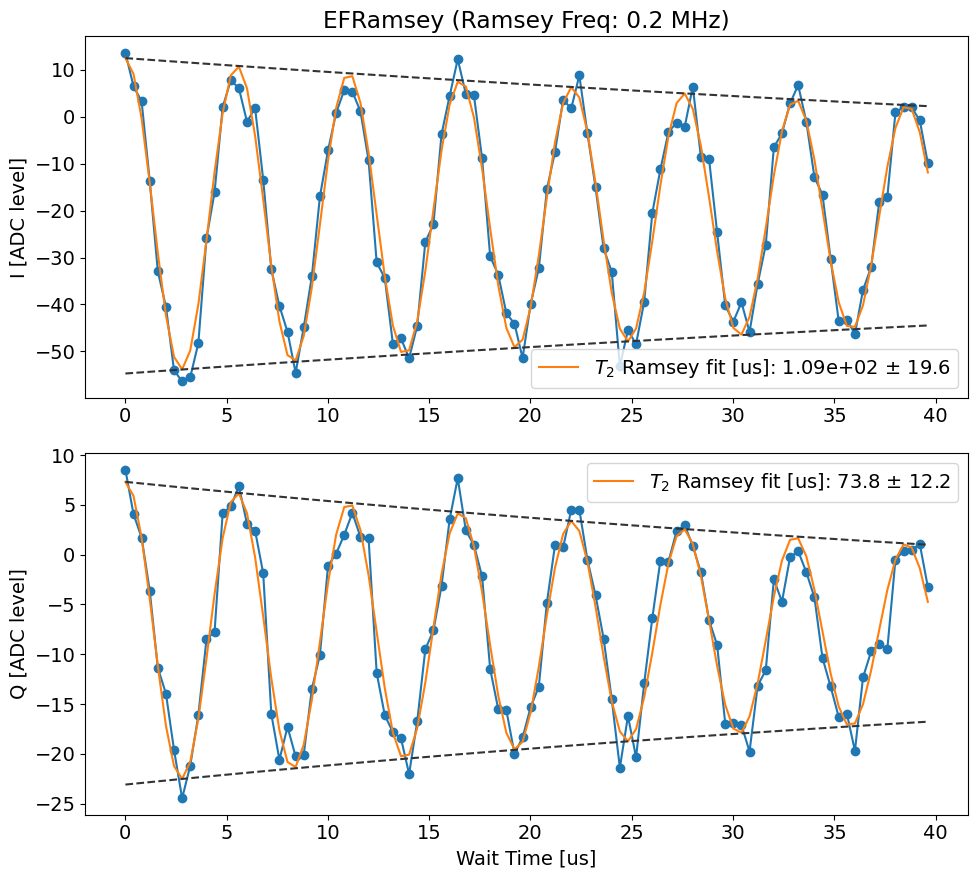

In [17]:
# Execute
# =================================
eframsey_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.RamseyExperiment,
    default_expt_cfg=eframsey_defaults,
    preprocessor=geramsey_preproc,  # Reuse ge preprocessor
    postprocessor=eframsey_postproc,
    job_client=client,
)

if expts_to_run['t2_ef']:
    t2ramsey_ef = eframsey_runner.execute(
        ramsey_freq=0.2,
        step = 0.4,
        relax_delay=2500,
        active_reset=True,
    )
    t2ramsey_ef.display()

In [ ]:
# station.preview_config_update()
station.snapshot_hardware_config(update_main=update_main)

### Amplitude Rabi

We should probably use a cosine fit with fixed phase=0 instead of decaying sine with varying phase?

In [ ]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
# Reuse ge defaults but with if_ef=True
efamprabi_defaults = AttrDict(deepcopy(amprabi_defaults))
efamprabi_defaults.if_ef = True
efamprabi_defaults.step = 120  # Typical ef amplitude step
efamprabi_defaults.expts = 150

def efamprabi_postproc(station, expt):
    station.hardware_cfg.device.qubit.pulses.pi_ef.gain = [expt.data['pi_gain_avgi']]
    station.hardware_cfg.device.qubit.pulses.hpi_ef.gain = [expt.data['hpi_gain_avgi']]
    print('Updated qubit ef pi and hpi gaussian gain!')
    station.snapshot_hardware_config(update_main=False)

In [ ]:
# Execute
# =================================
efamprabi_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.AmplitudeRabiExperiment,
    default_expt_cfg=efamprabi_defaults,
    preprocessor=amprabi_preproc,  # Reuse ge preprocessor
    postprocessor=efamprabi_postproc,
    job_client=client,
)

if expts_to_run['amplitude_ef']:
    amprabi_ef = efamprabi_runner.execute(
                relax_delay=2500,
    )
    amprabi_ef.display()
    
    # After amplitude calibration, do another T2 Ramsey to fine tune frequency
    t2_ramsey_ef_after_amp = eframsey_runner.execute(
        ramsey_freq=0.5,
        step = 0.1,
        relax_delay=2500,
    )
    t2_ramsey_ef_after_amp.display()

In [ ]:
station.preview_config_update()
station.snapshot_hardware_config(update_main=update_main)

### T1

In [18]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
t1_ef_defaults = AttrDict(dict(
    start=0,
    step=5,
    expts=100,
    reps=50,
    rounds=1,
    qubit=0,
    qubit_ef=True,
    normalize=False,
    relax_delay=2500,
))

def t1_ef_postproc(station, expt):
    station.hardware_cfg.device.qubit.T1_ef = [expt.data['fit_avgq'][3]]
    print('Updated qubit T1 ef!')
    station.snapshot_hardware_config(update_main=False)

Job submitted: JOB-20260708-00252 (queue position: 1)

[0.0s] Job JOB-20260708-00252: pending

[217.7s] Job JOB-20260708-00252: running
[WORKER] Loading T1Experiment from experiments.single_qubit.t1
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260708-00252_T1Experiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.3mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 66%|████████████████████████▏            | 3276/5000 [00:08<00:04, 372.82it/s]
[234.4s] Job JOB-20260708-00252: completed
100%|█████████████████████████████████████| 5000/5000 [00:13<00:00, 363.62it/s]
Saving C:\experiments\260526_Transduction\data\JOB-20260708-00252_T1Experiment.h5
[WORKER] Saving expt object to: C:\experiments\260526_Transduction\expt_objs\JOB-20260708-00252_expt.pkl

Job completed! Data: C:\experiments\260526_Transduction\data\JOB-20260708-00252_T1Experiment.h5
Updated qubit T1 ef!
[CONFIG] Created new hardware_config version CFG

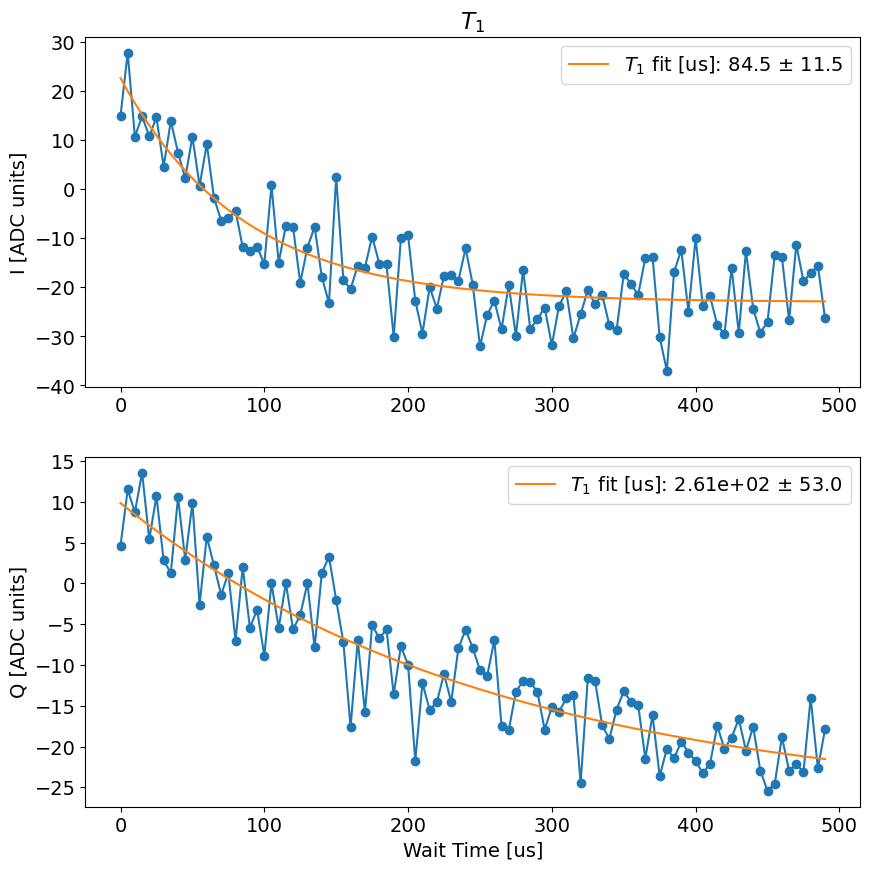

Fit T1 avgi [us]: 84.46664024461235
Fit T1 avgq [us]: 261.0894955711101


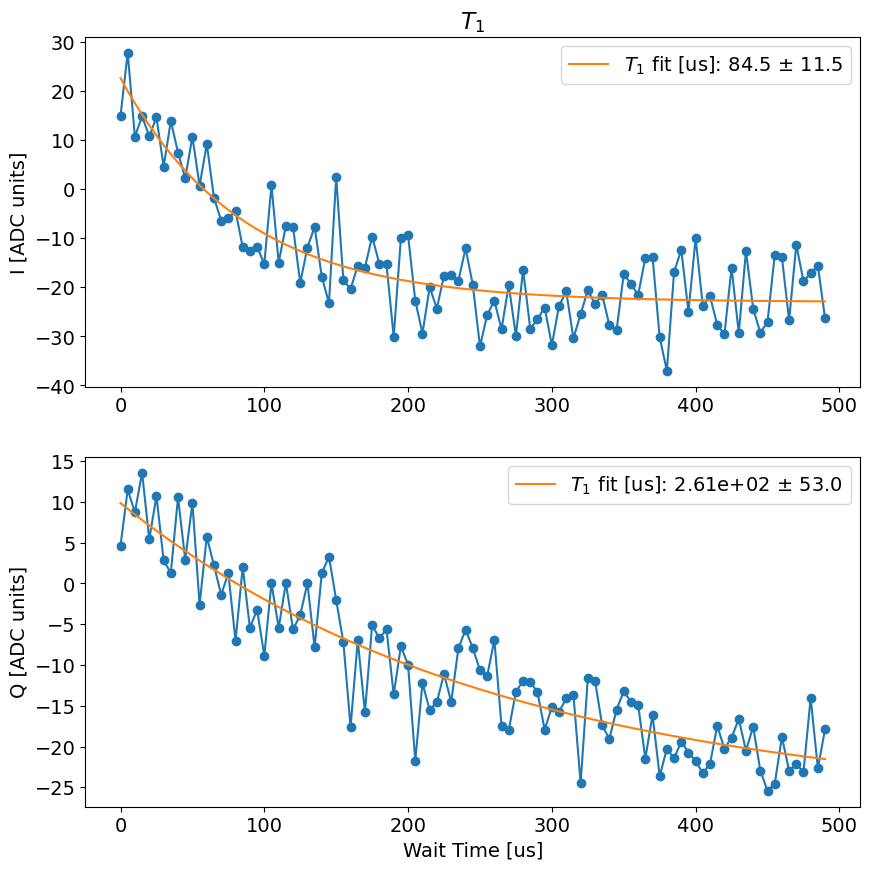

In [19]:
# Execute
# =================================
t1_ef_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.T1Experiment,
    default_expt_cfg=t1_ef_defaults,
    postprocessor=t1_ef_postproc,
    job_client=client,
)

if expts_to_run['t1_ef']:
    t1_ef = t1_ef_runner.execute()
    t1_ef.display()

In [20]:
# station.preview_config_update()
station.snapshot_hardware_config(update_main=update_main)

[CONFIG] Reusing existing hardware_config version CFG-HW-20260708-00108
[CONFIG] Updated main hardware_config to CFG-HW-20260708-00108


'CFG-HW-20260708-00108'

# Manipulate

## the config updates in this section need to be checked because there are many duplicate places to update

## Spectroscopy

In [ ]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
f0g1spec_defaults = AttrDict(dict(
    start=None,  # Will be computed in preprocessor from ds_storage
    step=0.2,
    expts=200,
    reps=100,
    rounds=1,
    length=1,
    gain=3000,
    pulse_type='gaussian',
    qubit_f=True,
    qubits=[0],
    prepulse=False,
    relax_delay=200,
))

def f0g1spec_preproc(station, default_expt_cfg, man_mode_no=1, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.man_mode_no = man_mode_no  # Store for postprocessor
    expt_cfg.update(kwargs)
    
    # Compute start frequency from dataset if not provided
    if expt_cfg.start is None:
        expt_cfg.start = station.ds_storage.get_freq('M' + str(man_mode_no)) - 20
    
    return expt_cfg

def f0g1spec_postproc(station, expt):
    man_mode_no = expt.cfg.expt.man_mode_no
    station.ds_storage.update_freq('M' + str(man_mode_no), expt.data['fit_avgi'][2])
    station.hardware_cfg.device.multiphoton['pi']['fn-gn+1']['frequency'][0] = expt.data['fit_avgi'][2]
    print(f"Updated man f0g1 freq to: {station.ds_storage.get_freq('M' + str(man_mode_no))}")
    station.snapshot_hardware_config(update_main=False)
    station.snapshot_multiphoton_config(update_main=False)

In [ ]:
# Execute
# =================================
f0g1spec_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.PulseProbeF0g1SpectroscopyExperiment,
    default_expt_cfg=f0g1spec_defaults,
    preprocessor=f0g1spec_preproc,
    postprocessor=f0g1spec_postproc,
    job_client=client,
)

man_specs = [None] * len(expts_to_run['man_modes'])

for i in range(len(expts_to_run['man_modes'])):
    if expts_to_run['pulse_probe_f0g1']:
        print(f'Running pulse probe f0g1 for mode {i+1}')
        man_specs[i] = f0g1spec_runner.execute(
            man_mode_no=i+1,
            go_kwargs=dict(progress=True),
            relax_delay=2500,
        )
        man_specs[i].display()


In [ ]:
station.preview_config_update()
# station.snapshot_hardware_config(update_main=True)
# station.snapshot_multiphoton_config(update_main=True)

## Find Frequency (Chevron)


In [ ]:
chevron_defaults = AttrDict(dict(
    start=2, # time start in us
    step=0.1, # time step in us
    expts=25, # number of time points
    reps=100,
    rounds=1,
    qubits=[0],
    gain=None, # Leave as None to use current value in dataset
    ramp_sigma=0.005,
    use_arb_waveform=False,
    pi_ge_before=True,
    pi_ef_before=True,
    pi_ge_after=False,
    normalize=False,
    active_reset=False,
    check_man_reset=[False, 0],
    check_man_reset_pi=[],
    prepulse=False,
    pre_sweep_pulse=[],
    err_amp_reps=0,
    swap_lossy=False,
))

# Postprocessor: extracts result from mother experiment and updates config
def my_postproc(station, mother_expt):
    """
    Postprocessor for chevron sweep.
    
    Args:
        station: MultimodeStation instance
        mother_expt: The mother experiment with 2D data and analysis results
    """
    # # Access the chevron analysis results
    # if hasattr(mother_expt, '_chevron_analysis') and mother_expt._chevron_analysis:
    #     analysis = mother_expt._chevron_analysis
    #     best_freq = analysis.results.get('best_frequency_contrast')
        
    #     if best_freq:
    #         print(f"Best frequency found: {best_freq:.4f} MHz")
            
    #         # Update dataset and config
    #         station.ds_storage.update_freq('M1', best_freq)
    #         station.hardware_cfg.device.multiphoton['pi']['fn-gn+1']['frequency'][0] = best_freq
    #         print(f"Updated M1 frequency to {best_freq:.4f} MHz")
    # else:
    #     print("No chevron analysis available")
    # station.snapshot_hardware_config(update_main=False)
    # station.snapshot_multiphoton_config(update_main=False)

    from fitting.fit_display_classes import ChevronFitting

    expt_cfg = mother_expt.cfg.expt

    chevron_analysis = ChevronFitting(
        frequencies=mother_expt.data['freq_sweep'],
        time=mother_expt.data['xpts'][0],
        response_matrix=mother_expt.data['avgi'],
        config=station.hardware_cfg,
        station=station,
    )
    chevron_analysis.analyze()
    best_freq = chevron_analysis.results.get('best_frequency_contrast')
    mother_expt.analysis = chevron_analysis

    if best_freq: 
        
        old_freq_pi = station.hardware_cfg.device.multiphoton['pi']['fn-gn+1']['frequency'][0] 
        station.hardware_cfg.device.multiphoton['pi']['fn-gn+1']['frequency'][0] = best_freq
        station.ds_storage.update_freq('M1', best_freq)
        print(f'  pi:  {old_freq_pi} -> {station.hardware_cfg.device.multiphoton['pi']['fn-gn+1']['frequency'][0] }')
    else: 
        print('No chevron analysis found in experiment.')

    chevron_analysis.display_results()


runner = SweepRunner(
    station=station,
    ExptClass=meas.LengthRabiGeneralF0g1Experiment,
    default_expt_cfg=chevron_defaults,
    sweep_param='freq',
    live_plot=False,
    # preprocessor=my_preproc,
    postprocessor=my_postproc,
    job_client=client,
)

In [ ]:
# coarse sweep
result = runner.execute(
    sweep_start=station.ds_storage.get_freq('M1') - 5,
    sweep_stop=station.ds_storage.get_freq('M1') + 1,
    sweep_npts=7,
    gain = station.ds_storage.get_gain('M1'),
    start = 1, # time start in us
)

In [ ]:
# fine sweep
result = runner.execute(
    sweep_start=station.ds_storage.get_freq('M1') - 1,
    # sweep_start=1996.3 - 1,
    sweep_stop=station.ds_storage.get_freq('M1') + 1,
    # sweep_stop=1996.3 + 1,
    sweep_npts=7,
    gain = station.ds_storage.get_gain('M1'),
    start = 1, # time start in us
)

## Error amplification

In [ ]:
# Manipulate/Error Amplification - New Pattern with CharacterizationRunner

# Configuration defaults
error_amp_defaults = AttrDict(dict(
    start=1998,
    expts=40,
    step=0.025,
    reps=100,
    rounds=1,
    qubit=0,
    qubits=[0],
    n_pulses=7,
    sideband = 'f0-g1', #should be in the format of 'fn-gn+1' 
    parameter_to_test='frequency',
    pulse_type= None, # if this is None, will be set to ['multiphoton', sideband, 'pi', 0] in preproc
    active_reset=False,
    man_reset=True,
    storage_reset=True,
    relax_delay=2500,
))

def error_amp_preproc(station, 
                      default_expt_cfg, 
                      **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    if expt_cfg.pulse_type is None:
        expt_cfg.pulse_type = ['multiphoton', expt_cfg.sideband, 'pi', 0]
    return expt_cfg

def error_amp_postproc(station, expt):
    """
    Postprocessor for error amplification.
    Analyze with custom parameters.
    """
    sideband = expt.cfg.expt.sideband
    _sideband = sideband[0] + 'n' + '-' + sideband[3] + 'n+1'
    i = int(sideband[1])
    # Perform analysis with state_fin='e' as in original code
    expt.analyze(data=expt.data, state_fin='e')
    # expt.display(data=expt.data, state_fin='e')
    print('Error amplification analysis complete')

    print(f"Man {sideband} pi frequency before update:", 
          station.hardware_cfg.device.multiphoton['pi'][_sideband]['frequency'][i])
    station.hardware_cfg.device.multiphoton['pi'][_sideband]['frequency'][i] = expt.data['fit_avgi'][2]
    print(f"Man {sideband} pi frequency after update:", 
          station.hardware_cfg.device.multiphoton['pi'][_sideband]['frequency'][i])
    if i > 0:
        print("WARNING! No update will occur! The update in this cell was meant for the csv which does not have multiphoton params. To update the multiphoton params, please run the multiphoton calibration notebook instead.")
    else:
        station.ds_storage.update_freq('M1', expt.data['fit_avgi'][2])
        print("Updated the ds_storage frequency to:", station.ds_storage.get_freq('M1'))
    station.snapshot_hardware_config(update_main=False)
    station.snapshot_multiphoton_config(update_main=False)

# Create runner
error_amp_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ErrorAmplificationExperiment,
    default_expt_cfg=error_amp_defaults,
    preprocessor=error_amp_preproc,
    postprocessor=error_amp_postproc,
    job_client=client,
)


In [ ]:
station.snapshot_man1_storage_swap(update_main=update_main)
station.snapshot_hardware_config(update_main=update_main)

In [ ]:
# Run with analyze=False, display=False initially
# Postprocessor will handle custom analysis
error_amp_exp = error_amp_runner.execute(
    start = station.ds_storage.get_freq('M1') - 0.5,
    step = 0.05,
    expts = 21,
    go_kwargs = dict(analyze=False, display=False),
    postprocess=True  # This will call postprocessor which does the custom analysis
)

error_amp_exp.display()

## Length Rabi f0g1 (Update time)

In [ ]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
lenrabi_f0g1_defaults = AttrDict(dict(
    start=None,  # Will be computed in preprocessor (soc.cycles2us(3))
    step=0.01,
    qubits=[0],
    expts=150,
    reps=100,
    rounds=1,
    gain=8000,
    freq=None,  # Will be set from ds_storage in preprocessor
    use_arb_waveform=False,
    pi_ge_before=True,
    pi_ef_before=True,
    pi_ge_after=True,
    normalize=False,
    active_reset=False,
    man_reset=True,
    stor_reset=True,
    check_man_reset=[False, 0],
    swap_lossy=False,
    check_man_reset_pi=[],
    prepulse=False,
    pre_sweep_pulse=[],
    err_amp_reps=0,
    relax_delay=5000,
))

def lenrabi_f0g1_preproc(station, default_expt_cfg, man_mode_no=1, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.man_mode_no = man_mode_no  # Store for postprocessor
    expt_cfg.update(kwargs)
    
    # Compute start and freq from soc and ds_storage if not provided
    if expt_cfg.start is None:
        expt_cfg.start = station.soccfg.cycles2us(3)
    if expt_cfg.freq is None:
        expt_cfg.freq = station.ds_storage.get_freq('M' + str(man_mode_no))
    
    return expt_cfg

def lenrabi_f0g1_postproc(station, expt):
    man_mode_no = expt.cfg.expt.man_mode_no
    
    # Get analysis results from the LengthRabiFitting object stored in expt
    if hasattr(expt, '_length_rabi_analysis'):
        analysis = expt._length_rabi_analysis
        pi_length = analysis.results['pi_length']
        pi2_length = analysis.results['pi2_length']
        gain = expt.cfg.expt.gain
        freq = expt.cfg.expt.freq

       
        station.ds_storage.update_all('M' + str(man_mode_no), freq, None, pi_length, pi2_length, gain)
        print(f'Updated dataset M{man_mode_no}: pi_length={pi_length:.4f}, pi2_length={pi2_length:.4f}, gain={gain}')

        station.snapshot_hardware_config(update_main=False)
        station.snapshot_multiphoton_config(update_main=False)


In [ ]:
# Execute
# =================================
lenrabi_f0g1_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.LengthRabiGeneralF0g1Experiment,
    default_expt_cfg=lenrabi_f0g1_defaults,
    preprocessor=lenrabi_f0g1_preproc,
    postprocessor=lenrabi_f0g1_postproc,
    job_client=client,
)

len_rabis_mans = [None] * len(expts_to_run['man_modes'])

for i in range(len(expts_to_run['man_modes'])):
    if expts_to_run['length_rabi'] or expts_to_run['length_rabi_sweep']:
        print(f'Running length rabi for mode {i+1}')
        len_rabis_mans[i] = lenrabi_f0g1_runner.execute(
            man_mode_no=i+1,
            go_kwargs=dict(progress=True)
        )
        len_rabis_mans[i].display()


In [ ]:
# len_rabis_mans[0].active_reset = True
# len_rabis_mans[0].analyze()
# len_rabis_mans[0].display(title_str='Length Rabi General F0g1')

## --- Manipulate sections below not refactored ---

## Chi between qubit and Manipulate 

### $\chi_\mathrm{ge}$

In [ ]:
# =====================================
# Define defaults and preprocessing (self-contained)
# =====================================
chi_ge_ramsey_defaults = AttrDict(dict(
    ramsey_freq=0.2,  # [MHz]
    start=0.01,  # us
    step=0.1,
    expts=100,
    reps=200,
    rounds=1,
    pre_sweep_pulse=None,
    post_sweep_pulse=None,
    if_ef=False,
    ef_init=True,
    qubits=[0],
    user_defined_freq=[False, 3568.2038290468167, 5304, 0.035],
    f0g1_cavity=0,
    normalize=False,
    active_reset=False,
    man_reset=False,
    storage_reset=False,
    prepulse=None,
    postpulse=None,
    pre_active_reset_pulse=False,
    gate_based=False,
    advance_phase=0,
    echoes=[False, 0],
    relax_delay=2500,
))

def chi_ge_ramsey_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    # Boolean logic for EF mode
    checkEF = False
    qubit_ge_init = False
    qubit_ge_after = False
    if expt_cfg.if_ef:
        checkEF = True
        qubit_ge_init = True if expt_cfg.ef_init else False
        qubit_ge_after = True if expt_cfg.ef_init else False
    expt_cfg.checkEF = checkEF
    expt_cfg.qubit_ge_init = qubit_ge_init
    expt_cfg.qubit_ge_after = qubit_ge_after

    expt_cfg.prepulse = False if expt_cfg.pre_sweep_pulse is None else True if expt_cfg.prepulse is None else expt_cfg.prepulse
    expt_cfg.postpulse = False if expt_cfg.post_sweep_pulse is None else True if expt_cfg.postpulse is None else expt_cfg.postpulse

    return expt_cfg

# =====================================
# Create runner
# =====================================
chi_ge_ramsey_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.RamseyExperiment,
    default_expt_cfg=chi_ge_ramsey_defaults,
    preprocessor=chi_ge_ramsey_preproc,
    postprocessor=None,  # We don't want to update f_ge from chi measurement
    job_client=client,
)

# =====================================
# Chi update function
# =====================================
def update_chi_ge(t2_standard, t2_prepulse, station, man_mode_no=1):
    """Compute chi from two Ramsey experiments and update station config."""
    f_without = t2_standard.data['f_adjust_ramsey_avgi'][0]
    f_with = t2_prepulse.data['f_adjust_ramsey_avgi'][0]
    chi = f_with - f_without
    print(f'Chi: {chi}')
    station.hardware_cfg.device.manipulate.chi_ge[man_mode_no - 1] = chi
    chi_ge = np.abs(np.pi / (2 * np.pi * chi))
    print(f'Chi_ge (us): {chi_ge}')
    return chi




In [ ]:
# =====================================
# Execute
# =====================================
if expts_to_run['chi_ge']:
    man_mode_no = 1

    # Standard Ramsey (no prepulse)
    t2_standard = chi_ge_ramsey_runner.execute(
        ramsey_freq=0.4,
        step=0.05,
        expts=100,
        active_reset=False,
        relax_delay=2500,
    )
    t2_standard.display()


    prep_man_pi = mm_base_calib.prep_man_photon(man_mode_no)
    prepulse = mm_base_calib.get_prepulse_creator(prep_man_pi).pulse.tolist()

    # Ramsey with prepulse
    t2_prepulse = chi_ge_ramsey_runner.execute(
        ramsey_freq=0.2,
        step=0.1,
        expts=100,
        active_reset=False,
        relax_delay=2500,
        pre_sweep_pulse=prepulse,
    )

    t2_prepulse.display()

In [ ]:
if expts_to_run['chi_ge']:
    update_chi_ge(t2_standard, t2_prepulse, station, man_mode_no=man_mode_no)

### $\chi_\mathrm{ef}$

In [ ]:
# =====================================
# Define defaults and preprocessing (self-contained)
# =====================================
chi_ef_ramsey_defaults = AttrDict(dict(
    ramsey_freq=0.5,
    start=0.01,
    step=0.1,
    expts=100,
    reps=200,
    rounds=1,
    pre_sweep_pulse=None,
    post_sweep_pulse=None,
    if_ef=True,
    ef_init=True,
    qubits=[0],
    user_defined_freq=[False, 3568.2038290468167, 5304, 0.035],
    f0g1_cavity=0,
    normalize=False,
    active_reset=True,
    man_reset=False,
    storage_reset=False,
    prepulse=None,
    postpulse=None,
    pre_active_reset_pulse=False,
    gate_based=False,
    advance_phase=0,
    echoes=[False, 0],
    relax_delay=2500,
))

def chi_ef_ramsey_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    # Boolean logic for EF mode
    checkEF = False
    qubit_ge_init = False
    qubit_ge_after = False
    if expt_cfg.if_ef:
        checkEF = True
        qubit_ge_init = True if expt_cfg.ef_init else False
        qubit_ge_after = True if expt_cfg.ef_init else False
    expt_cfg.checkEF = checkEF
    expt_cfg.qubit_ge_init = qubit_ge_init
    expt_cfg.qubit_ge_after = qubit_ge_after

    expt_cfg.prepulse = False if expt_cfg.pre_sweep_pulse is None else True if expt_cfg.prepulse is None else expt_cfg.prepulse
    expt_cfg.postpulse = False if expt_cfg.post_sweep_pulse is None else True if expt_cfg.postpulse is None else expt_cfg.postpulse

    return expt_cfg

# =====================================
# Create runner
# =====================================
chi_ef_ramsey_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.RamseyExperiment,
    default_expt_cfg=chi_ef_ramsey_defaults,
    preprocessor=chi_ef_ramsey_preproc,
    postprocessor=None,  # We don't want to update f_ef from chi measurement
    job_client=client,
)

# =====================================
# Chi ef update function
# =====================================
def update_chi_ef(t2_ef_standard, t2_ef_prepulse, station, man_mode_no=1):
    """Compute chi_ef from two ef Ramsey experiments and update station config."""
    f_without = t2_ef_standard.data['f_adjust_ramsey_avgi'][0]
    f_with = t2_ef_prepulse.data['f_adjust_ramsey_avgi'][0]
    chi_ef = f_with - f_without
    print(f'Chi EF: {chi_ef}')
    station.hardware_cfg.device.manipulate.chi_ef[man_mode_no - 1] = chi_ef
    return chi_ef


In [ ]:

# =====================================
# Execute
# =====================================
if expts_to_run['chi_ef']:
    man_mode_no = 1

    # Standard EF Ramsey (no prepulse)
    t2_ef_standard = chi_ef_ramsey_runner.execute(
        ramsey_freq=0.5,
        step=0.1,
        expts=100,
        active_reset=True,
        relax_delay=2500,
        postprocess=True,
    )
    t2_ef_standard.display()

    # Build prepulse for manipulate mode
    prep_man_pi = mm_base_calib.prep_man_photon(man_mode_no)
    prepulse = mm_base_calib.get_prepulse_creator(prep_man_pi).pulse.tolist()

    # EF Ramsey with prepulse
    t2_ef_prepulse = chi_ef_ramsey_runner.execute(
        ramsey_freq=0.5,
        step=0.1,
        expts=100,
        active_reset=True,
        relax_delay=2500,
        pre_sweep_pulse=prepulse,
        postprocess=True,
    )
    t2_ef_prepulse.display()



In [ ]:
if expts_to_run['chi_ef']:
    update_chi_ef(t2_ef_standard, t2_ef_prepulse, station, man_mode_no=man_mode_no)

In [ ]:
station.preview_config_update()

## Man-Dump 

### Spectroscopy

In [ ]:
def get_dump_mode_parameters(ds_storage, config_thisrun, man_mode_no, dump_mode_no):
    """Get pulse parameters for a given dump mode."""
    dump_name = 'M' + str(man_mode_no) + '-D' + str(dump_mode_no)
    freq = ds_storage.get_freq(dump_name)
    gain = ds_storage.get_gain(dump_name)
    pi_len = ds_storage.get_pi(dump_name)
    h_pi_len = ds_storage.get_h_pi(dump_name)
    flux_low_ch = config_thisrun.hw.soc.dacs.flux_low.ch
    flux_high_ch = config_thisrun.hw.soc.dacs.flux_high.ch
    # ch = flux_low_ch if freq < 1000 else flux_high_ch
    ch = 4 
    print('Flux channel manually set to 4')

    mm_base_dummy = MM_dual_rail_base(config_thisrun, soccfg=station.soccfg)
    prepulse_spec = [['multiphoton', 'g0-e0', 'pi', 0],
                     ['multiphoton', 'e0-f0', 'pi', 0],
                     ['multiphoton', 'f0-g1', 'pi', 0]]
    postpulse_spec = [['multiphoton', 'f0-g1', 'pi', 0],
                      ['multiphoton', 'e0-f0', 'pi', 0]]
    prepulse = mm_base_dummy.get_prepulse_creator(prepulse_spec).pulse.tolist()
    postpulse = mm_base_dummy.get_prepulse_creator(postpulse_spec).pulse.tolist()

    return freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse

In [ ]:
# Configuration defaults
dump_spec_defaults = AttrDict(dict(
    # step=0.5,  # bw/expts = 100/200
    step=0.2,  # bw/expts = 100/200
    expts=200,
    reps=200,
    qubit=[0],
    flux_drive=[0, 1, 5000, 5],  # [ch, freq_placeholder, gain, length(us)]
    flux_gain=5000,
    flux_length=5,
    prepulse=True,
    postpulse=True,
    active_reset=False,
    man_reset=False,
    storage_reset=False,
    relax_delay=2500,
))

def dump_spec_preproc(station, default_expt_cfg, man_mode_no=1, dump_mode_no=1, **kwargs):
    """Preprocessor for dump spectroscopy."""
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    
    # Get dump mode parameters
    freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse = get_dump_mode_parameters(
        station.ds_storage, station.hardware_cfg, man_mode_no, dump_mode_no
    )
    print(f'Using dump mode parameters: freq={freq}, gain={gain}, pi_len={pi_len}, h_pi_len={h_pi_len}, ch={ch}')

    freq = 2310.0  # Temporary fix for testing
    
    # Set sweep range centered on current frequency
    bw = expt_cfg.expts * expt_cfg.step  # Total bandwidth
    expt_cfg.start = freq - bw/2
    expt_cfg.step = bw / expt_cfg.expts
    print(f'Set sweep start to {expt_cfg.start} MHz with step {expt_cfg.step} MHz')
    
    # Set flux drive channel and prepulse/postpulse
    expt_cfg.flux_drive = [ch, 1, expt_cfg.flux_gain, expt_cfg.flux_length]
    expt_cfg.pre_sweep_pulse = prepulse
    expt_cfg.post_sweep_pulse = postpulse
    
    print(f'Dump spectroscopy for M{man_mode_no}-D{dump_mode_no}: freq={freq:.3f} MHz, bw={bw} MHz')
    
    return expt_cfg

def dump_spec_postproc(station, expt, man_mode_no=1, dump_mode_no=1):
    """Postprocessor for dump spectroscopy - updates frequency."""
    dump_name = f'M{man_mode_no}-D{dump_mode_no}'
    new_freq = expt.data['fit_avgi'][2]
    station.ds_storage.update_freq(dump_name, new_freq)
    print(f'Updated frequency for {dump_name}: {new_freq:.4f} MHz')



In [ ]:
# Create runner
dump_spec_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.FluxSpectroscopyF0g1Experiment,
    default_expt_cfg=dump_spec_defaults,
    preprocessor=dump_spec_preproc,
    # postprocessor=dump_spec_postproc,
    job_client=client,
)

# Execute for dump modes
if expts_to_run.get('dump_spectroscopy', True):
    dump_specs = {}
    for dump_mode_no in [1]:  # specify which dump modes to run
        print(f'Running dump spectroscopy for mode {dump_mode_no}')
        dump_specs[dump_mode_no] = dump_spec_runner.execute(
            man_mode_no=1,
            dump_mode_no=dump_mode_no,
            flux_gain=8000,
            flux_length=5,
            step=0.1,  # bw/expts = 100/200
            expts=4000,
            reps=400,
        )
        dump_specs[dump_mode_no].display()

### Dump chevron

In [ ]:
from fitting.fit_display_classes import ChevronFitting
from datetime import datetime

# Configuration defaults for dump sideband sweep
dump_sideband_chevron_defaults = AttrDict(dict(
    start=0.007, # start time in us
    pi_len_sweep=2.0, # total sweep length in us
    expts=30, # num steps of time
    reps=50,
    rounds=1,
    qubit=0,
    qubits=[0],
    man_mode_no=1,
    prepulse=True,
    postpulse=True,
    active_reset=False,
    man_reset=True,
    storage_reset=True,
    update_post_pulse_phase=[False, 0],
    relax_delay=2500,
))

def dump_sideband_chevron_preproc(station, default_expt_cfg, **kwargs):
    assert 'dump_mode_no' in kwargs
    
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    
    # Get dump mode parameters
    freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse = get_dump_mode_parameters(
        station.ds_storage, station.hardware_cfg, expt_cfg.man_mode_no, expt_cfg.dump_mode_no
    )

    print('Prepulse:', prepulse)
    print('Postpulse:', postpulse)

    dump_name = f'M{expt_cfg.man_mode_no}-D{expt_cfg.dump_mode_no}'
    
    pi_len_sweep = expt_cfg.pi_len_sweep
    expt_cfg.step = pi_len_sweep / (expt_cfg.expts - 1)
    if 'gain' in expt_cfg and expt_cfg.gain is not None:
        gain = expt_cfg.gain  # Override gain if provided
    
    expt_cfg.flux_drive = [ch, freq, gain, 0]
    expt_cfg.pre_sweep_pulse = prepulse
    expt_cfg.post_sweep_pulse = postpulse
    
    print(f'Dump sideband chevron for {dump_name}: freq={freq:.3f} MHz, gain={gain}')
    
    return expt_cfg

def dump_sideband_chevron_postproc(station, mother_expt):
    expt_cfg = mother_expt.cfg.expt
    dump_name = f'M{expt_cfg.man_mode_no}-D{expt_cfg.dump_mode_no}'

    from fitting.fit_display_classes import ChevronFitting

    chevron_analysis = ChevronFitting(
        frequencies=mother_expt.data['freq_sweep'],
        time=mother_expt.data['xpts'][0],
        response_matrix=mother_expt.data['avgi'],
        config=station.hardware_cfg,
        station=station,
    )

    # chevron_analysis.analyze()
    
    # best_freq = chevron_analysis.results.get('best_frequency_contrast')
        
    # if best_freq:
    #     print(f"Best frequency found: {best_freq:.4f} MHz")
    #     station.ds_storage.update_freq(dump_name, best_freq)
    #     print(f"Updated {dump_name} frequency to {best_freq:.4f} MHz")
    #     pi_len = abs(np.pi / chevron_analysis.results['best_fit_params_period']['omega'])
    #     station.ds_storage.update_pi(dump_name, pi_len)
    #     print('Updated the pi length to:', pi_len)
    #     station.ds_storage.update_h_pi(dump_name, pi_len / 2)
    #     print('Updated the h_pi length to:', pi_len / 2)
    #     station.ds_storage.update_gain(dump_name, expt_cfg.flux_drive[2])
    #     print('Updated gain to:', expt_cfg.flux_drive[2])
    # mother_expt.analysis = chevron_analysis
    # station.snapshot_man1_storage_swap(update_main=False)

dump_sideband_chevron_runner = SweepRunner(
    station=station,
    ExptClass=meas.single_qubit.sideband_general.SidebandGeneralExperiment,
    default_expt_cfg=dump_sideband_chevron_defaults,
    sweep_param='freq',
    preprocessor=dump_sideband_chevron_preproc,
    postprocessor=dump_sideband_chevron_postproc,
    job_client=client,
)


In [ ]:
# Run dump chevron for specified dump mode
dump_mode_no = 1
man_mode_no = 1

print(f'Running dump sideband chevron for M{man_mode_no}-D{dump_mode_no}')

# Get current frequency for sweep range
dump_name = f'M{man_mode_no}-D{dump_mode_no}'
center_freq = station.ds_storage.get_freq(dump_name)
freq_bw = 0.6  # MHz bandwidth for frequency sweep

dump_chevron = dump_sideband_chevron_runner.execute(
    dump_mode_no=dump_mode_no,
    man_mode_no=man_mode_no,
    sweep_start=center_freq - freq_bw/2,
    sweep_stop=center_freq + freq_bw/2,
    sweep_pts=6,
    pi_len_sweep=2.0,
    expts=30,
    reps=50,
)

dump_chevron.analysis.display()


In [ ]:
# from experiments.MM_dual_rail_base import MM_dual_rail_base
# mm_base_dummy = MM_dual_rail_base(config_thisrun, soccfg=soc)
# prep_man_pi = mm_base_dummy.prep_man_photon(1)
# prepulse = mm_base_dummy.get_prepulse_creator(prep_man_pi).pulse.tolist()
# postpulse = mm_base_dummy.get_prepulse_creator(prep_man_pi[-1:-3:-1]).pulse.tolist() # for ge meas, only do f0g1 and ef pi

In [ ]:
def get_dump_mode_parameters(ds_storage, config_thisrun, man_mode_no, dump_mode_no):
    """
    Get pulse parameters for a given storage mode. 
    Also returns prepulse and postpulse (single photon prep and meas for ge meas)

    Args:
        ds_storage: Dataset object for managing frequency data.
        config_thisrun: Configuration dictionary for the current run.
        man_mode_no: Manipulation mode number.
        dump_mode_no: Dump mode number.

    Returns:
        A tuple containing freq, gain, ch, prepulse, and postpulse.
    """
    stor_name = 'M' + str(man_mode_no) + '-D' + str(dump_mode_no)
    freq = ds_storage.get_freq(stor_name)
    gain = ds_storage.get_gain(stor_name)
    pi_len = ds_storage.get_pi(stor_name)
    h_pi_len = ds_storage.get_h_pi(stor_name)
    ch = 'low' if freq < 1000 else 'high'

    from experiments.MM_dual_rail_base import MM_dual_rail_base
    mm_base_dummy = MM_dual_rail_base(config_thisrun, soccfg=soc)
    prep_man_pi = mm_base_dummy.prep_man_photon(man_mode_no)
    prepulse = mm_base_dummy.get_prepulse_creator(prep_man_pi).pulse.tolist()
    postpulse = mm_base_dummy.get_prepulse_creator(prep_man_pi[-1:-3:-1]).pulse.tolist() # for ge meas, only do f0g1 and ef pi

    prepulse_overwrite = [['multiphoton', 'g0-e0', 'pi', 0],
                            ['multiphoton', 'e0-f0', 'pi', 0],
                            ['multiphoton', 'f0-g1', 'pi', 0]
                        ]
    postpulse_overwrite = [ ['multiphoton', 'f0-g1', 'pi', 0],
                            ['multiphoton', 'e0-f0', 'pi', 0]]
    prepulse = mm_base_dummy.get_prepulse_creator(prepulse_overwrite).pulse.tolist()
    postpulse = mm_base_dummy.get_prepulse_creator(postpulse_overwrite).pulse.tolist()

    return freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse


def do_dump_spectroscopy(config_thisrun, 
                         ds_storage, 
                         expt_path, 
                         config_path, 
                         man_mode_no = 1, 
                         dump_no = 1,
                         flux_gain = 5000,
                         flux_length = 1):
    """
    Run the Flux Spectroscopy F0g1 Experiment.

    This function performs a flux spectroscopy experiment to measure the transition frequency
    between the f0 and g1 states of a qubit. It configures the experiment parameters, executes
    the experiment, and saves the results.

    Args:
        config_thisrun (AttrDict): Configuration dictionary for the current run.
        ds_storage (dataset.storage_man_swap_dataset): Dataset object for managing frequency data.
        expt_path (str): Path to save the experiment results.
        config_path (str): Path to the configuration file.
        man_mode_no (int, optional): Manipulation mode number (default is 1).
        dump_no (int, optional): Storage mode number (default is 1).

    Returns:
        FluxSpectroscopyF0g1Experiment: The experiment object containing the results.
    """
    flux_spec = meas.single_qubit.rf_flux_spectroscopy_f0g1.FluxSpectroscopyF0g1Experiment(
        soccfg=soc, path=expt_path, prefix='FluxSpectroscopyF0g1Experiment', config_file=config_path
    )

    flux_spec.cfg = AttrDict(deepcopy(config_thisrun))

    freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse = get_dump_mode_parameters(ds_storage, config_thisrun,
                                                                      man_mode_no, dump_no)

    freq_start = 2300 #2350 
    freq_stop = 2400 #2400
    bw = freq_stop - freq_start
    expts = 200
    step = bw/expts



    flux_spec.cfg.expt = dict(
        # start=freq - 100,  # Start RF frequency [MHz]
        start=freq_start,  # Start RF frequency [MHz]
        step=step,  # Step size [MHz]
        expts=expts,  # Number of experiments
        reps=200,  # Number of averages per point
        qubit=[0],
        flux_drive=[ch, 1, flux_gain, flux_length],  # RF flux modulation parameters [low/high (ch), freq (will be overwritten), gain, length(us)]
        prepulse=True,
        postpulse=True,
        active_reset=False,
        man_reset=False,
        storage_reset=False,
        pre_sweep_pulse= prepulse,
        post_sweep_pulse= postpulse,
    )

    flux_spec.cfg.device.readout.relax_delay = [2500]  # Wait time between experiments [us]
    flux_spec.go(analyze=False, display=False, progress=True, save=True)
    return flux_spec


def update_dump_spectroscopy(flux_spec, ds_storage, man_mode_no = 1, dump_no = 1):
    """Update the configuration based on Flux Spectroscopy F0g1 experiment results."""
    # Update the dataset with the new frequency
    ds_storage.update_freq('M' + str(man_mode_no) + '-D' + str(dump_no), flux_spec.data['fit'][2])
    print(f"Updated frequency for M{man_mode_no}-D{dump_no}: {flux_spec.data['fit'][2]}")


In [ ]:
spec = do_dump_spectroscopy(config_thisrun, ds_storage, expt_path, config_path, 
                            man_mode_no=1, dump_no=1,
                            flux_gain=8000, flux_length=5)
# analyze_and_display_stor_spectroscopy(spec)
# update_dump_spectroscopy(spec, ds_storage, 1, 1)
spec.analyze(fit=True)
spec.display()

In [ ]:
spec.analyze(fit=True, fitparams=[800, 100, 40, 0, 60, 0, 0])
spec.display()

## T1 (do be updated, exist in multiphoton calibration already)

In [ ]:
def do_t1_manipulate(config_thisrun, expt_path, config_path, man_mode_no=1):
    """
    Run T1 experiment for the specified manipulate mode (man_mode_no).
    """
    t1_man = meas.single_qubit.t1_cavity.T1CavityExperiment(
        soccfg=soc, path=expt_path, prefix='T1CavityExperiment', config_file=config_path
    )

    t1_man.cfg = AttrDict(deepcopy(config_thisrun))

    # Set experiment parameters for the specified manipulate mode
    t1_man.cfg.expt = dict(
        start=0,
        step=15,
        expts=60,
        reps=300,
        rounds=1,
        cavity_prepulse=[False, 300, 1.5],
        f0g1_prep=True,
        f0g1_param=[ds_storage.get_freq(f'M{man_mode_no}'), ds_storage.get_gain(f'M{man_mode_no}'), ds_storage.get_pi(f'M{man_mode_no}')],
        resolved_pi=False,
        cavity=man_mode_no,
        qubit=0,
        normalize=False
    )

    t1_man.cfg.device.readout.relax_delay = [2500]
    t1_man.go(analyze=True, display=True, progress=True, save=True)
    return t1_man



In [ ]:
t1_man = do_t1_manipulate(config_thisrun, expt_path, config_path, 1)

## T2 (same as above)
06/19/2025: The code below should use man ramsey directly instead of user defined; user defined is for ramsey where you directly displace manipulate mode  - Eesh

In [ ]:
def do_cavity_ramsey(config_thisrun, expt_path, config_path, man_mode_no=1):
    """
    Run the Cavity Ramsey experiment using the specified configuration.
    """
    cavity_ramsey = meas.single_qubit.t2_cavity.CavityRamseyExperiment(
        soccfg=soc, path=expt_path, prefix='CavityRamseyExperiment', config_file=config_path
    )

    cavity_ramsey.cfg = AttrDict(deepcopy(config_thisrun))

    # Prepulse and postpulse

    # Set experiment parameters as in the YAML block above
    cavity_ramsey.cfg.expt = dict(
        start=0.01,
        step=0.02*7.5,
        expts=600,
        # ramsey_freq=-3.5,
        ramsey_freq=1.5,
        reps=100,
        rounds=1,
        qubits=[0],
        checkEF=False,
        f0g1_cavity=0,
        init_gf=False,
        active_reset=False,
        man_reset=True,
        storage_reset=True,
        user_defined_pulse=[False, ds_storage.get_freq(stor_name='M'+ str(man_mode_no)), 
                            ds_storage.get_gain(stor_name='M'+ str(man_mode_no)), 0.005, 
                            ds_storage.get_pi(stor_name='M'+ str(man_mode_no)), 0],
        parity_meas=False,
        man_mode_no=man_mode_no ,
        storage_ramsey=[False, 2, True],
        man_ramsey=[True, man_mode_no],
        coupler_ramsey=False,
        custom_coupler_pulse=[[944.25], [1000], [0.316677658], [0], [1], ['flat_top'], [0.005]],
        echoes=[True, 1],
        prepulse=True,
        postpulse=True,
        gate_based = True,
        pre_sweep_pulse= [['qubit', 'ge', 'hpi', 0], ['qubit', 'ef', 'pi', 0]],
        post_sweep_pulse=[['qubit', 'ef', 'pi', 0], ['qubit', 'ge', 'hpi', 0]]
    )

    cavity_ramsey.cfg.device.readout.relax_delay = [2500]
    cavity_ramsey.go(analyze=False, display=False, progress=True, save=True)
    return cavity_ramsey

cavity_ramsey = do_cavity_ramsey(config_thisrun, expt_path, config_path, man_mode_no=1)

In [ ]:
cavity_ramsey.analyze(fitparams=[300, None, None, None, None, None])
cavity_ramsey.display()

# Storage

In [7]:
# Storage Spectroscopy - New Pattern with CharacterizationRunner
from experiments.MM_dual_rail_base import MM_dual_rail_base

In [8]:
# Helper function (kept from original)
def get_storage_mode_parameters(ds_storage, config_thisrun, man_mode_no, stor_mode_no):
    """Get pulse parameters for a given storage mode."""
    stor_name = 'M' + str(man_mode_no) + '-S' + str(stor_mode_no)
    freq = ds_storage.get_freq(stor_name)
    gain = ds_storage.get_gain(stor_name)
    pi_len = ds_storage.get_pi(stor_name)
    h_pi_len = ds_storage.get_h_pi(stor_name)
    ch = 'low' if freq < 1800 else 'high'

    mm_base_dummy = MM_dual_rail_base(config_thisrun, soccfg=station.soccfg)
    prep_man_pi = mm_base_dummy.prep_man_photon(man_mode_no)
    print(f'Preparation manual pi: {prep_man_pi}')
    print('post pulse spec:', prep_man_pi[-1:-3:-1])
    prepulse = mm_base_dummy.get_prepulse_creator(prep_man_pi).pulse.tolist()
    postpulse = mm_base_dummy.get_prepulse_creator(prep_man_pi[-1:-3:-1]).pulse.tolist()

    return freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse


In [ ]:
get_storage_mode_parameters(station.ds_storage, station.hardware_cfg, 1, 1)

## Man-Stor Spectroscopy

Running storage spectroscopy for mode 4
Preparation manual pi: [['multiphoton', 'g0-e0', 'pi', 0], ['multiphoton', 'e0-f0', 'pi', 0], ['multiphoton', 'f0-g1', 'pi', 0]]
post pulse spec: [['multiphoton', 'f0-g1', 'pi', 0], ['multiphoton', 'e0-f0', 'pi', 0]]
Fetched storage mode parameters: freq=873.1271680729757, gain=5151, pi_len=2.2728833615417146, h_pi_len=1.1364416807708573, ch=low
Using storage mode parameters: freq=873.1271680729757, gain=1000, length=5, ch=low
Storage spectroscopy for M1-S4: freq=873.127 MHz, bw=8.0 MHz, using channel low
Job submitted: JOB-20260708-00364 (queue position: 1)

[0.0s] Job JOB-20260708-00364: pending

[2.0s] Job JOB-20260708-00364: running
[WORKER] Loading FluxSpectroscopyF0g1Experiment from experiments.single_qubit.rf_flux_spectroscopy_f0g1
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260708-00364_FluxSpectroscopyF0g1Experiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.32mA according to hardwa

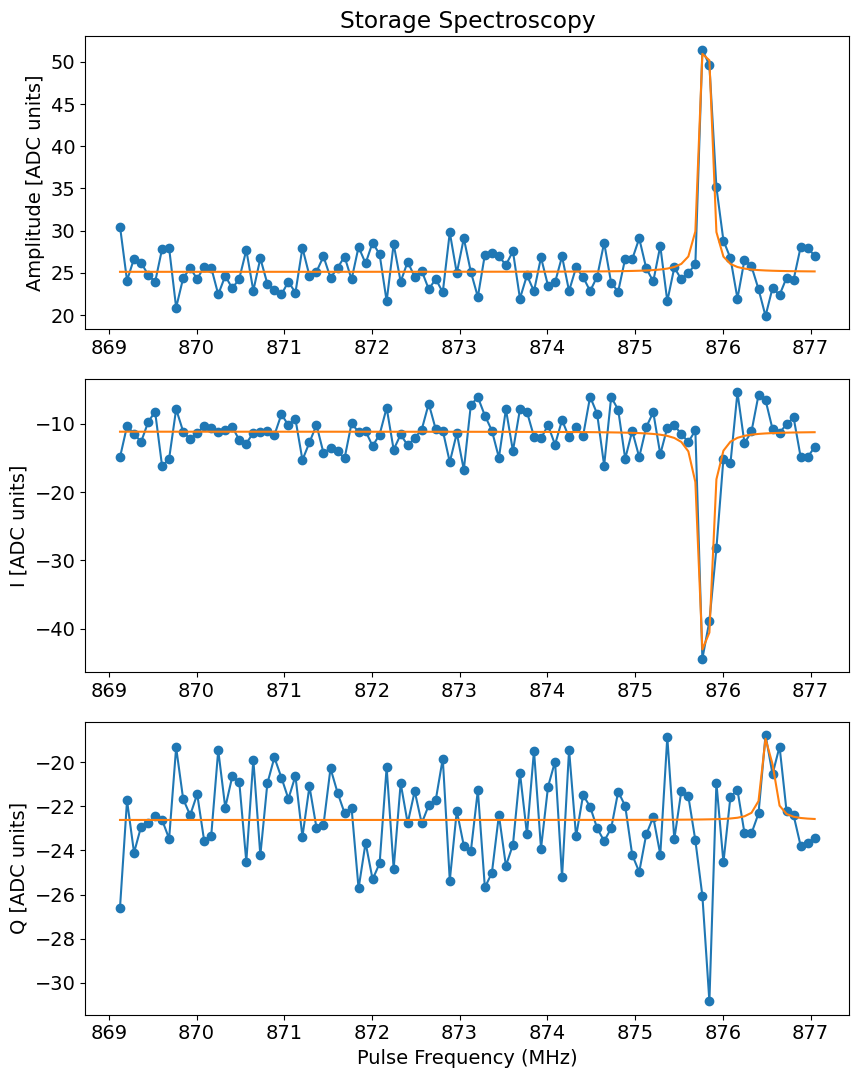

Found peak in amps at [MHz] 875.8066156690653, HWHM 0.036578557175976384
Found peak in I at [MHz] 875.8051949068271, HWHM 0.04809076462339151
Found peak in Q at [MHz] 876.517447766333, HWHM 0.049884777950587635


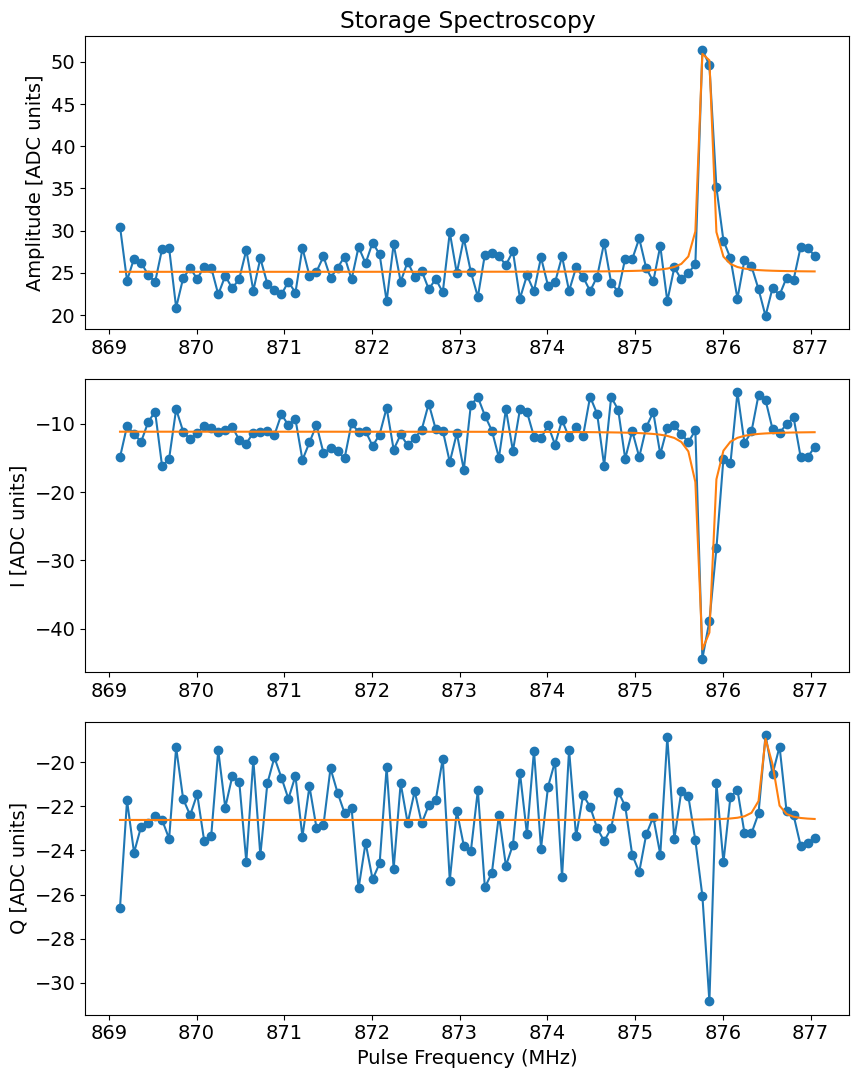

In [9]:
# Configuration defaults
stor_spec_defaults = AttrDict(dict(
    step=0.08,  # bw/expts = 20/250
    expts=250,
    reps=200,
    qubit=[0],
    flux_drive=[0, 1, 3000, 5],  # [ch, freq_placeholder, gain, length(us)]
    freq=None, 
    gain=None,
    length=None,
    prepulse=True,
    postpulse=True,
    active_reset=False,
    relax_delay=500,
))

def stor_spec_preproc(station, default_expt_cfg, man_mode_no=1, stor_mode_no=1, **kwargs):
    """Preprocessor for storage spectroscopy."""
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.man_mode_no = man_mode_no   # stash for postprocessor
    expt_cfg.stor_mode_no = stor_mode_no # stash for postprocessor
    expt_cfg.update(kwargs)
    
    # Get storage mode parameters
    _freq, _gain, _pi_len, h_pi_len, ch, prepulse, postpulse = get_storage_mode_parameters(
        station.ds_storage, station.hardware_cfg, man_mode_no, stor_mode_no
    )

    # _freq = 873.3622106690557

    print(f'Fetched storage mode parameters: freq={_freq}, gain={_gain}, pi_len={_pi_len}, h_pi_len={h_pi_len}, ch={ch}')   


    bw = expt_cfg.step * expt_cfg.expts

    if expt_cfg.freq is None:
        expt_cfg.freq = _freq
    if expt_cfg.gain is None:
        expt_cfg.gain = _gain
    if expt_cfg.length is None:
        expt_cfg.length = _pi_len
    print(f'Using storage mode parameters: freq={expt_cfg.freq}, gain={expt_cfg.gain}, length={expt_cfg.length}, ch={ch}')
    
    # Set sweep range centered on current frequency
    expt_cfg.start = expt_cfg.freq - bw/2
    expt_cfg.step = bw / expt_cfg.expts
    
    # Set flux drive channel and prepulse/postpulse
    expt_cfg.flux_drive = [ch, expt_cfg.flux_drive[1], expt_cfg.gain, expt_cfg.length]  # Update channel, gain, and length, keep placeholder freq
    expt_cfg.pre_sweep_pulse = prepulse
    expt_cfg.post_sweep_pulse = postpulse
    
    print(f'Storage spectroscopy for M{man_mode_no}-S{stor_mode_no}: freq={expt_cfg.freq:.3f} MHz, bw={bw} MHz, using channel {ch}')
    
    return expt_cfg

def stor_spec_postproc(station, expt):
    """Postprocessor for storage spectroscopy - updates frequency."""
    man_mode_no = expt.cfg.expt.man_mode_no
    stor_mode_no = expt.cfg.expt.stor_mode_no
    stor_name = f'M{man_mode_no}-S{stor_mode_no}'
    new_freq = expt.data['fit_avgi'][2]
    station.ds_storage.update_freq(stor_name, new_freq)
    print(f'Updated frequency for {stor_name}: {new_freq:.4f} MHz')


# Create runner
stor_spec_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.FluxSpectroscopyF0g1Experiment,
    default_expt_cfg=stor_spec_defaults,
    preprocessor=stor_spec_preproc,
    postprocessor=stor_spec_postproc,
    job_client=client,
)

# Execute for all storage modes
if expts_to_run.get('stor_spectroscopy', False):
    stor_specs = {}
    # for stor_mode_no in range(1, 8):  # modes 1-7
    for stor_mode_no in [4]:  # modes 1-7
        print(f'Running storage spectroscopy for mode {stor_mode_no}')
        stor_specs[stor_mode_no] = stor_spec_runner.execute(
            man_mode_no=1,
            stor_mode_no=stor_mode_no,
            gain=1000,
            length=5,
            step=0.08,  # bw/expts = 20/250
            # step=0.25,  # bw/expts = 20/250
            expts=100,
            reps=200,
        )
        stor_specs[stor_mode_no].display()

### Save dataset and update to main if desired

In [ ]:
station.snapshot_man1_storage_swap(update_main=False)
# station.snapshot_man1_storage_swap(update_main=True)

In [ ]:
station.ds_storage.get_freq('M1-S2')


In [ ]:
res = []

gains = np.arange(500, 2001, 50)
for flux_gain in tqdm(gains):
    spec = do_dump_spectroscopy(config_thisrun, ds_storage, expt_path, config_path, 
                                man_mode_no=1, dump_no=1,
                                flux_gain=flux_gain, flux_length=1)
    res.append(spec.data['avgi'])
res = np.array(res)

In [ ]:
means = res.mean(axis=1)
stds = res.std(axis=1)
plt.errorbar(gains, means, yerr=stds, marker='o')

In [ ]:
# ds_storage.update_freq('M1-D1',  2373.6)

In [ ]:
for i in range(len(expts_to_run['stor_modes'])):
    print('Frequency for M1-S' + str(i+1) + ':', ds_storage.get_freq('M1-S' + str(i+1)))


## Man-coupler (to be updated)

In [ ]:
def get_coupler_parameters(ds_storage, config_thisrun, man_mode_no):
    """
    Get pulse parameters for a given storage mode. 
    Also returns prepulse and postpulse (single photon prep and meas for ge meas)

    Args:
        ds_storage: Dataset object for managing frequency data.
        config_thisrun: Configuration dictionary for the current run.
        man_mode_no: Manipulation mode number.
        dump_mode_no: Dump mode number.

    Returns:
        A tuple containing freq, gain, ch, prepulse, and postpulse.
    """
    stor_name = 'M' + str(man_mode_no) + '-C'
    freq = ds_storage.get_freq(stor_name)
    gain = ds_storage.get_gain(stor_name)
    pi_len = ds_storage.get_pi(stor_name)
    h_pi_len = ds_storage.get_h_pi(stor_name)
    ch = 'low' if freq < 1000 else 'high'

    from experiments.MM_dual_rail_base import MM_dual_rail_base
    mm_base_dummy = MM_dual_rail_base(config_thisrun, soccfg=soc)
    prep_man_pi = mm_base_dummy.prep_man_photon(man_mode_no)
    prepulse = mm_base_dummy.get_prepulse_creator(prep_man_pi).pulse.tolist()
    postpulse = mm_base_dummy.get_prepulse_creator(prep_man_pi[-1:-3:-1]).pulse.tolist() # for ge meas, only do f0g1 and ef pi

    prepulse_overwrite = [['multiphoton', 'g0-e0', 'pi', 0],
                            ['multiphoton', 'e0-f0', 'pi', 0],
                            ['multiphoton', 'f0-g1', 'pi', 0]
                        ]
    postpulse_overwrite = [ ['multiphoton', 'f0-g1', 'pi', 0],
                            ['multiphoton', 'e0-f0', 'pi', 0]]
    prepulse = mm_base_dummy.get_prepulse_creator(prepulse_overwrite).pulse.tolist()
    postpulse = mm_base_dummy.get_prepulse_creator(postpulse_overwrite).pulse.tolist()

    return freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse


def do_coupler_spectroscopy(config_thisrun, 
                         ds_storage, 
                         expt_path, 
                         config_path, 
                         man_mode_no = 1, 
                         dump_no = 1,
                         flux_gain = 5000,
                         flux_length = 1):
    """
    Run the Flux Spectroscopy F0g1 Experiment.

    This function performs a flux spectroscopy experiment to measure the transition frequency
    between the f0 and g1 states of a qubit. It configures the experiment parameters, executes
    the experiment, and saves the results.

    Args:
        config_thisrun (AttrDict): Configuration dictionary for the current run.
        ds_storage (dataset.storage_man_swap_dataset): Dataset object for managing frequency data.
        expt_path (str): Path to save the experiment results.
        config_path (str): Path to the configuration file.
        man_mode_no (int, optional): Manipulation mode number (default is 1).
        dump_no (int, optional): Storage mode number (default is 1).

    Returns:
        FluxSpectroscopyF0g1Experiment: The experiment object containing the results.
    """
    flux_spec = meas.single_qubit.rf_flux_spectroscopy_f0g1.FluxSpectroscopyF0g1Experiment(
        soccfg=soc, path=expt_path, prefix='FluxSpectroscopyF0g1Experiment', config_file=config_path
    )

    flux_spec.cfg = AttrDict(deepcopy(config_thisrun))

    freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse = get_coupler_parameters(ds_storage, config_thisrun,
                                                                      man_mode_no)

    # freq = 420

    flux_spec.cfg.expt = dict(
        start=freq - 50,  # Start RF frequency [MHz]
        step=1,  # Step size [MHz]
        expts=100,  # Number of experiments
        reps=200,  # Number of averages per point
        qubit=[0],
        flux_drive=[ch, 1, flux_gain, flux_length],  # RF flux modulation parameters [low/high (ch), freq (will be overwritten), gain, length(us)]
        prepulse=True,
        postpulse=True,
        active_reset=False,
        man_reset=False,
        storage_reset=False,
        pre_sweep_pulse= prepulse,
        post_sweep_pulse= postpulse,
    )

    flux_spec.cfg.device.readout.relax_delay = [2500]  # Wait time between experiments [us]
    flux_spec.go(analyze=False, display=False, progress=True, save=True)
    return flux_spec


def update_dump_spectroscopy(flux_spec, ds_storage, man_mode_no = 1):
    """Update the configuration based on Flux Spectroscopy F0g1 experiment results."""
    # Update the dataset with the new frequency
    ds_storage.update_freq('M' + str(man_mode_no) + '-C', flux_spec.data['fit'][2])
    print(f"Updated frequency for M{man_mode_no}-C: {flux_spec.data['fit'][2]}")

ds_storage.update_freq('M' + str(1) + '-C', 919)

In [ ]:
spec = do_coupler_spectroscopy(config_thisrun, ds_storage, expt_path, config_path, man_mode_no=1,
                            flux_gain=10000, flux_length=2)
# analyze_and_display_stor_spectroscopy(spec)
# update_dump_spectroscopy(spec, ds_storage, 1, 1)
spec.analyze(fit=True)
spec.display()

## Freq Chevron

In [10]:
from fitting.fit_display_classes import ChevronFitting
from datetime import datetime

# Configuration defaults for sideband sweep
sideband_chevron_defaults = AttrDict(dict(
    start=0.007, # start time in us
    pi_len_sweep=2.0, # total sweep length in us
    expts=30, # num steps of time
    reps=50,
    rounds=1,
    qubit=0,
    qubits=[0],
    man_mode_no=1,
    prepulse=True,
    postpulse=True,
    active_reset=False,
    man_reset=True,
    storage_reset=True,
    update_post_pulse_phase=[False, 0],
    relax_delay=2500,
))

def sideband_chevron_preproc(station, default_expt_cfg, **kwargs):
    assert 'stor_mode_no' in kwargs
    
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    
    # Get storage mode parameters
    freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse = get_storage_mode_parameters(
        station.ds_storage, station.hardware_cfg, expt_cfg.man_mode_no, expt_cfg.stor_mode_no
    )

    stor_name = f'M{expt_cfg.man_mode_no}-S{expt_cfg.stor_mode_no}'
    
    pi_len_sweep = expt_cfg.pi_len_sweep
    expt_cfg.step = pi_len_sweep / (expt_cfg.expts - 1)
    if 'gain' in expt_cfg and expt_cfg.gain is not None:
        gain = expt_cfg.gain  # Override gain if provided
    
    expt_cfg.flux_drive = ['low', freq, gain, 0]
    expt_cfg.pre_sweep_pulse = prepulse
    expt_cfg.post_sweep_pulse = postpulse
    
    print(f'Sideband chevron for {stor_name}: freq={freq:.3f} MHz, gain={gain}')
    
    return expt_cfg

def sideband_chevron_postproc(station, mother_expt):
    expt_cfg = mother_expt.cfg.expt
    stor_name = f'M{expt_cfg.man_mode_no}-S{expt_cfg.stor_mode_no}'

    from fitting.fit_display_classes import ChevronFitting

    chevron_analysis = ChevronFitting(
        frequencies=mother_expt.data['freq_sweep'],
        time=mother_expt.data['xpts'][0],
        response_matrix=mother_expt.data['avgi'],
        config=station.hardware_cfg,
        station=station,
    )

    chevron_analysis.analyze()
    
    best_freq = chevron_analysis.results.get('best_frequency_contrast')
        
    if best_freq:
        print(f"Best frequency found: {best_freq:.4f} MHz")
        station.ds_storage.update_freq(stor_name, best_freq)
        print(f"Updated {stor_name} frequency to {best_freq:.4f} MHz")
        pi_len = abs(np.pi / chevron_analysis.results['best_fit_params_period']['omega'])
        station.ds_storage.update_pi(stor_name, pi_len)
        print('Updated the pi length to:', pi_len)
        station.ds_storage.update_h_pi(stor_name, pi_len / 2)
        print('Updated the h_pi length to:', pi_len / 2)
        station.ds_storage.update_gain(stor_name, expt_cfg.flux_drive[2])
        print('Updated gain to:', expt_cfg.flux_drive[2])
    mother_expt.analysis = chevron_analysis
    station.snapshot_man1_storage_swap(update_main=False)

sideband_chevron_runner = SweepRunner(
    station=station,
    ExptClass=meas.single_qubit.sideband_general.SidebandGeneralExperiment,
    default_expt_cfg=sideband_chevron_defaults,
    sweep_param='freq',
    preprocessor=sideband_chevron_preproc,
    postprocessor=sideband_chevron_postproc,
    job_client=client,
)

Running sideband chevron for M1-S4
gain: 4635, pi_len_sweep: 5.0, freq_span: 0.3, freq_step: 0.1
freq before sweep: 875.8051949068271
Preparation manual pi: [['multiphoton', 'g0-e0', 'pi', 0], ['multiphoton', 'e0-f0', 'pi', 0], ['multiphoton', 'f0-g1', 'pi', 0]]
post pulse spec: [['multiphoton', 'f0-g1', 'pi', 0], ['multiphoton', 'e0-f0', 'pi', 0]]
Sideband chevron for M1-S4: freq=875.805 MHz, gain=4635
Sweep: freq from 875.6551949068271 to 875.955194906827 (3 pts)
  File: C:\experiments\260526_Transduction\data\00024_SidebandGeneralExperiment_sweep.h5
  Submitting 3 jobs...
Job submitted: JOB-20260708-00365 (queue position: 1)
Job submitted: JOB-20260708-00366 (queue position: 1)
Job submitted: JOB-20260708-00367 (queue position: 3)
  All 3 jobs submitted. Waiting for results...
  [1/3] freq=875.6552 [WORKER] Loading SidebandGeneralExperiment from experiments.single_qubit.sideband_general
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260708-00365_SidebandGeneralExp

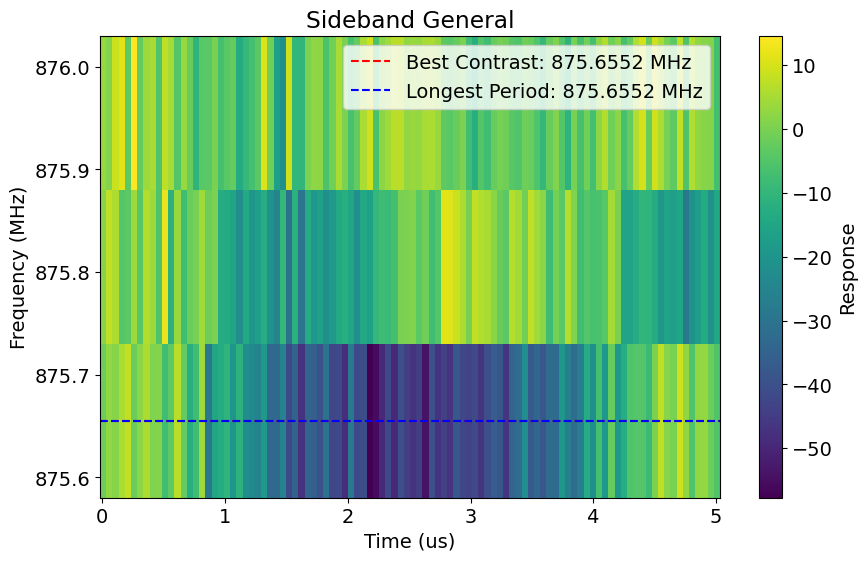

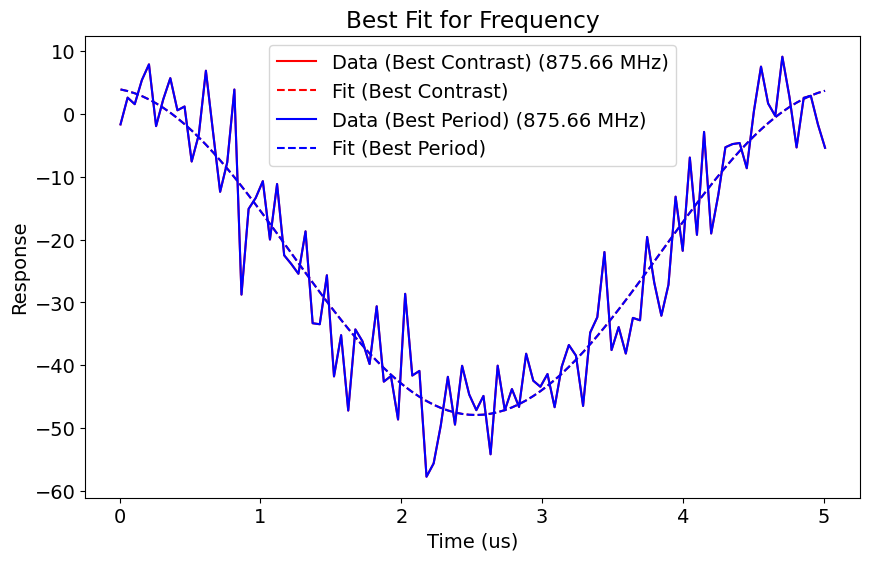

[log_measurement] Appended section to G:\Shared drives\SLab\Multimode\Lab\seb\Transduction\2026\07\2026-07-08.md
freq after sweep: 875.6551949068271


In [11]:
if expts_to_run.get('sideband_freq_sweep', False):
    # for stor_i in expts_to_run.get('stor_modes', [1]):
    for stor_i in [4]:
        stor_name = f'M1-S{stor_i}'

        freq_span = 0.3
        freq_step = 0.1
        # freq_step = 0.1
        # pi_len_sweep = 5.0
        pi_len_sweep = 5.0
        gain = int(station.ds_storage.get_gain(stor_name)*0.9)
        
        print(f'Running sideband chevron for {stor_name}')
        print(f'gain: {gain}, pi_len_sweep: {pi_len_sweep}, freq_span: {freq_span}, freq_step: {freq_step}')
        print('freq before sweep:', station.ds_storage.get_freq(stor_name))
        chevron_analysis = sideband_chevron_runner.execute(
            # reps=50,
            stor_mode_no=stor_i,
            sweep_start=station.ds_storage.get_freq(stor_name) - freq_span/2,
            sweep_stop=station.ds_storage.get_freq(stor_name) + freq_span/2,
            sweep_npts=int(freq_span//freq_step + 1),
            pi_len_sweep=pi_len_sweep,
            expts=100,
            gain=gain,
            batch=True,
        )
        print('freq after sweep:', station.ds_storage.get_freq(stor_name))
        # chevron_analysis.analysis.display_results()

In [12]:
station.snapshot_man1_storage_swap(update_main=True)

[CONFIG] Reusing existing man1_storage_swap version CFG-M1-20260708-00015
[CONFIG] Updated main man1_storage_swap to CFG-M1-20260708-00015


'CFG-M1-20260708-00015'

## Error amplification

In [13]:
error_amp_gain1 = [None] * len(expts_to_run['stor_modes'])
error_amp_freq1 = [None] * len(expts_to_run['stor_modes'])
error_amp_gain2 = [None] * len(expts_to_run['stor_modes'])
error_amp_freq2 = [None] * len(expts_to_run['stor_modes'])

In [14]:
error_amp_stor_defaults = AttrDict(dict(
    reps=50,
    rounds=1,
    qubits=[0],
    man_mode_no=1,
    stor_is_dump=False,
    active_reset=False,
    man_reset=True,
    storage_reset=True,
    relax_delay=2500, 
    expts=30,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

error_amp_gain_stor_coarse_defaults = AttrDict(dict(
    n_start=0,
    n_step=3,
    n_pulses=15,
    expts=50,
))

error_amp_freq_stor_coarse_defaults = AttrDict(dict(
    n_start=0,
    n_step=1,
    n_pulses=5,
    expts=50,
))


def error_amp_stor_preproc(station, default_expt_cfg, **kwargs):
    assert 'stor_mode_no' in kwargs
    assert 'parameter_to_test' in kwargs 

    # construct the defaults
    expt_cfg = deepcopy(default_expt_cfg)
    if kwargs['parameter_to_test'] == 'gain':
        expt_cfg.update(error_amp_gain_stor_coarse_defaults)
    elif kwargs['parameter_to_test'] == 'frequency':
        expt_cfg.update(error_amp_freq_stor_coarse_defaults)

    # override with the passed kwargs
    expt_cfg.update(kwargs)

    stor_mode_no = expt_cfg.stor_mode_no    
    man_mode_no = expt_cfg.man_mode_no

    freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse = get_storage_mode_parameters(
        station.ds_storage, station.hardware_cfg, man_mode_no, stor_mode_no
        )
    print(f"Previous freq {freq}, gain {gain}, pi_len {pi_len}")

    if 'span' not in expt_cfg:
        if expt_cfg.parameter_to_test == 'gain':
            expt_cfg.span = int(gain * 0.3)
        elif expt_cfg.parameter_to_test == 'frequency':
            expt_cfg.span = 0.15 # MHz
  
    stor_name = f'M{man_mode_no}-S{stor_mode_no}'
    pulse_type = ['storage', stor_name, 'pi', 0]

    if expt_cfg.parameter_to_test == 'frequency':
        start = freq - expt_cfg.span / 2
        step = expt_cfg.span / (expt_cfg.expts - 1)
    elif expt_cfg.parameter_to_test == 'gain':
        start = int(gain - expt_cfg.span / 2)
        step = int(expt_cfg.span / (expt_cfg.expts - 1))
    else:
        raise ValueError("parameter_to_test must be either 'frequency' or 'gain'.")
    expt_cfg.start = start
    expt_cfg.step = step
    expt_cfg.pulse_type = pulse_type 
    return expt_cfg

def error_amp_stor_postproc(station, expt):
    expt.analyze(data=expt.data, state_fin='e')

    opt_gain = expt.data['fit_avgi'][2]
    stor_name = 'M1-S' + str(expt.cfg.expt.stor_mode_no)
    if expt.cfg.expt.parameter_to_test == 'gain':
        station.ds_storage.update_gain(stor_name, opt_gain)
    elif expt.cfg.expt.parameter_to_test == 'frequency':
        station.ds_storage.update_freq(stor_name, opt_gain)
    station.snapshot_man1_storage_swap(update_main=False)


error_amp_stor_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ErrorAmplificationExperiment,
    default_expt_cfg=error_amp_stor_defaults,
    preprocessor=error_amp_stor_preproc,
    postprocessor=error_amp_stor_postproc,
    job_client=client,
)

In [15]:
freq, gain, pi_len, h_pi_len, ch, prepulse, postpulse = get_storage_mode_parameters(
        station.ds_storage, station.hardware_cfg, 1, 4
        )
print(f"Before error amp optimization - freq {freq}, gain {gain}, pi_len {pi_len}")

Preparation manual pi: [['multiphoton', 'g0-e0', 'pi', 0], ['multiphoton', 'e0-f0', 'pi', 0], ['multiphoton', 'f0-g1', 'pi', 0]]
post pulse spec: [['multiphoton', 'f0-g1', 'pi', 0], ['multiphoton', 'e0-f0', 'pi', 0]]
Before error amp optimization - freq 875.6551949068271, gain 4635, pi_len 2.6361176600384444


Running M1-S4
Preparation manual pi: [['multiphoton', 'g0-e0', 'pi', 0], ['multiphoton', 'e0-f0', 'pi', 0], ['multiphoton', 'f0-g1', 'pi', 0]]
post pulse spec: [['multiphoton', 'f0-g1', 'pi', 0], ['multiphoton', 'e0-f0', 'pi', 0]]
Previous freq 875.7318362883889, gain 4143, pi_len 2.6361176600384444
Job submitted: JOB-20260708-00370 (queue position: 1)

[0.0s] Job JOB-20260708-00370: pending

[2.0s] Job JOB-20260708-00370: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260708-00370_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.32mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 86%|█████████████████████████████████████▋      | 6/7 [00:57<00:09,  9.65s/it]
[70.4s] Job JOB-20260708-00370: completed
100%|████████████████████████████████████████████| 7/7 [01:07<00:00,  9.63s/it]
Savin

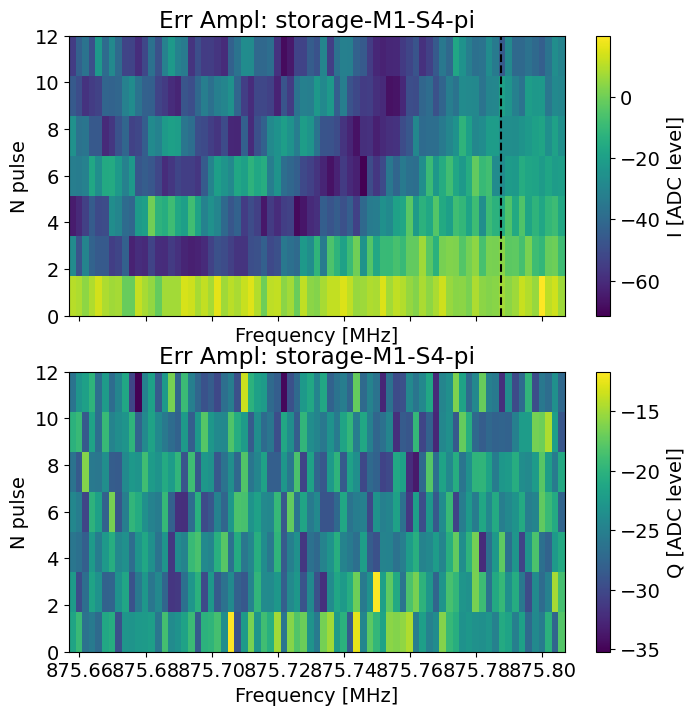

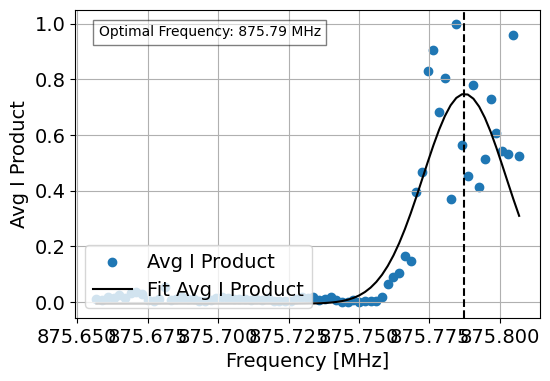

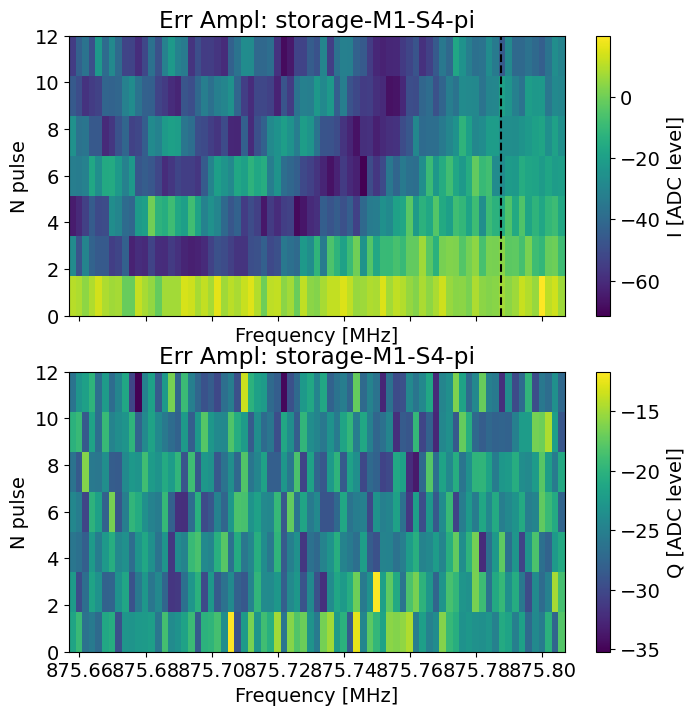

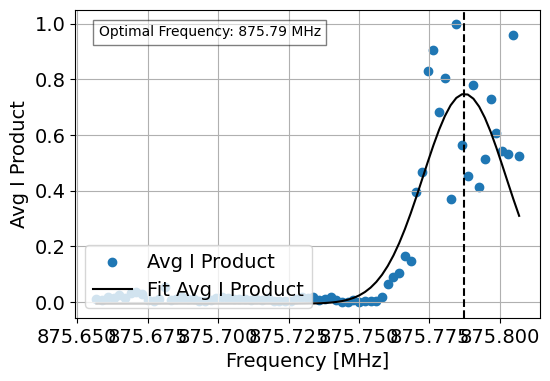

Preparation manual pi: [['multiphoton', 'g0-e0', 'pi', 0], ['multiphoton', 'e0-f0', 'pi', 0], ['multiphoton', 'f0-g1', 'pi', 0]]
post pulse spec: [['multiphoton', 'f0-g1', 'pi', 0], ['multiphoton', 'e0-f0', 'pi', 0]]
Previous freq 875.7874398411328, gain 4143, pi_len 2.6361176600384444
Job submitted: JOB-20260708-00371 (queue position: 1)

[0.0s] Job JOB-20260708-00371: pending

[2.0s] Job JOB-20260708-00371: running
[WORKER] Loading ErrorAmplificationExperiment from experiments.single_qubit.error_amplification
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260708-00371_ErrorAmplificationExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.32mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 86%|█████████████████████████████████████▋      | 6/7 [00:57<00:09,  9.65s/it]
[68.4s] Job JOB-20260708-00371: completed
100%|████████████████████████████████████████████| 7/7 [01:07<00:00,  9.62s/it]
Saving C:\experimen

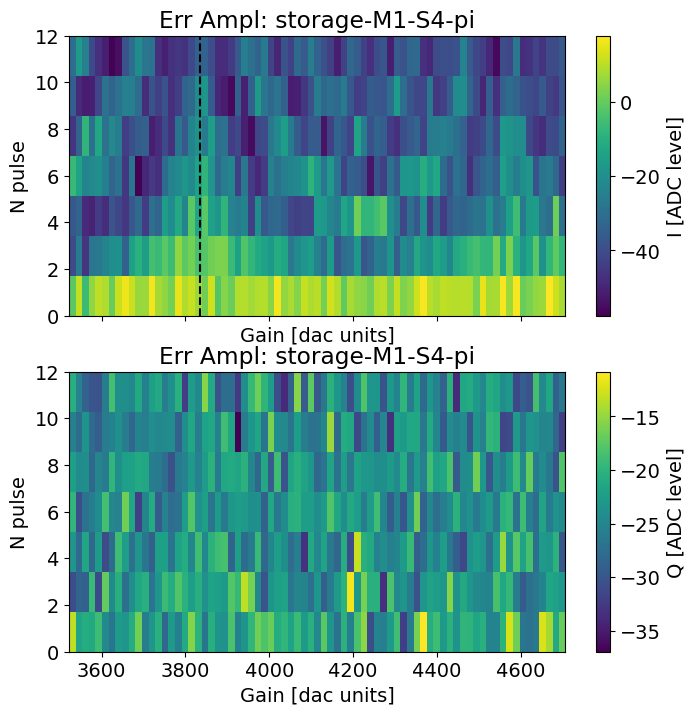

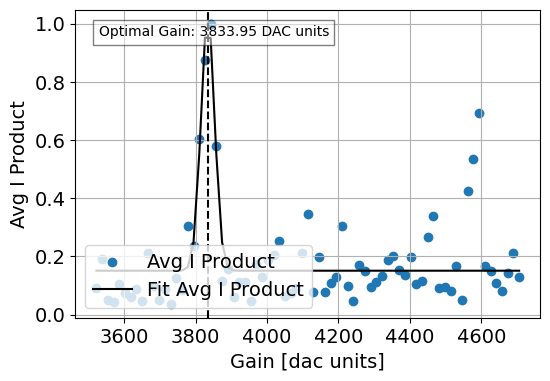

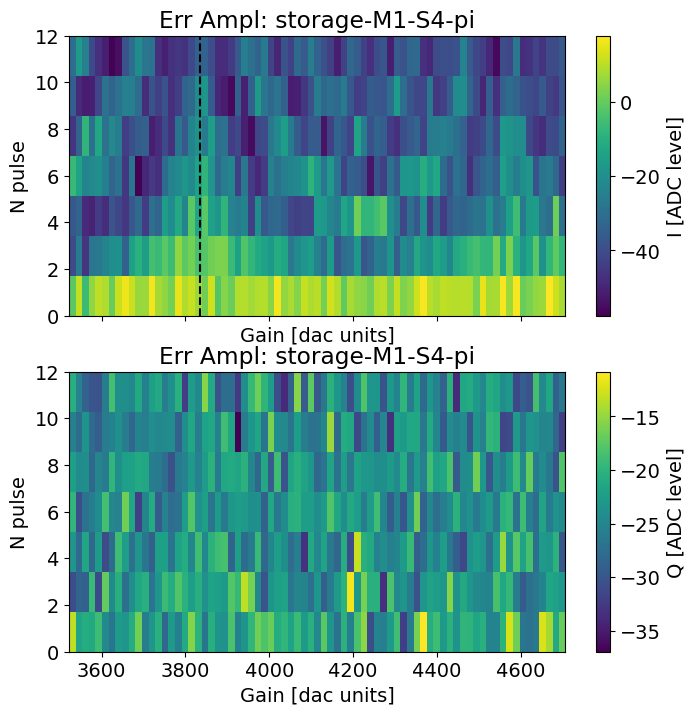

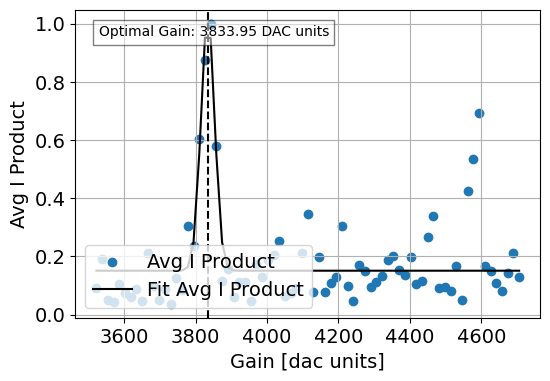

In [17]:
# for i, stor_i in enumerate(stor_modes_to_run):
# for i, stor_i in enumerate(expts_to_run.get('stor_modes', [1])):

for i, stor_i in enumerate([4]):
# for i, stor_i in enumerate([7]):
    stor_name = 'M1-S' + str(stor_i)
    print("Running", stor_name)
    error_amp_freq1[i] = error_amp_stor_runner.execute(
        stor_mode_no=stor_i,
        parameter_to_test='frequency',
        # span=0.025,
        span=0.15,
        expts = 75,
        n_start=0,
        n_step=2,
        # n_pulses=20,
        n_pulses=11,
    )
    error_amp_freq1[i].display()

    error_amp_gain1[i] = error_amp_stor_runner.execute(
        stor_mode_no=stor_i,
        parameter_to_test='gain',  
        n_start=0,
        n_step=2,
        expts = 75, 
        # n_pulses=20,
        n_pulses=11,
    )
    error_amp_gain1[i].display()

In [18]:
station.snapshot_man1_storage_swap(update_main=True)

[CONFIG] Reusing existing man1_storage_swap version CFG-M1-20260708-00019
[CONFIG] Updated main man1_storage_swap to CFG-M1-20260708-00019


'CFG-M1-20260708-00019'

In [ ]:
# save new dataset to current_dataset path
station.ds_storage.save_to_file(
    station.config_dir / station.hardware_cfg.device.storage.storage_man_file
)

In [ ]:
ds_storage.get_all('M1-S1')
# ds_storage.update_freq('M1-S1', 354.25)
# ds_storage.update_gain('M1-S1', 3500)

In [ ]:
ds_storage.df

In [ ]:
# for i, stor_i in enumerate(expts_to_run['stor_modes']):
#     if stor_i != 4: continue
#     # if stor_i == 5: continue

#     stor_name = 'M1-S' + str(stor_i)
#     print(stor_name)
#     ds.update_gain(stor_name, ds_storage.get_gain(stor_name))
#     ds.update_freq(stor_name, ds_storage.get_freq(stor_name))
#     ds.update_pi(stor_name, ds_storage.get_pi(stor_name))
#     ds.update_h_pi(stor_name, ds_storage.get_h_pi(stor_name))

In [ ]:
for i in range(len(expts_to_run['stor_modes'])):
    print('Frequency for M1-S' + str(i+1) + ':', ds_storage.get_freq('M1-S' + str(i+1)))

In [ ]:
# #Update sweep data and analyze results

# temp_data, attrs, filename = prev_data(expt_path, prefix='sideband_general_sweep')
# print('File saved at:', filename)

# from fitting.fit_display_classes import ChevronFitting
# from datetime import datetime
# chevron_analysis = ChevronFitting(
#     frequencies=temp_data['freq_sweep'],
#     time=temp_data['xpts'][0],
#     response_matrix=temp_data['avgi'],
#     config = config_thisrun,
# )
# chevron_analysis.analyze()

# current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
# chevron_analysis.display_results(save_fig=True,  title=f'M{1}-S{7}_{current_time}')

In [ ]:
# i = 5
# print(f'Running fine sideband sweep for storage mode {i + 1}')
# freq_start = ds_storage.get_freq('M1-S' + str(i + 1)) - 1.5
# freq_stop = ds_storage.get_freq('M1-S' + str(i + 1)) + 1.5
# freq_step = 0.2
# sideband_chevrons_fine = do_sideband_general_sweep(
#     config_thisrun, ds_storage, expt_path, config_path, freq_start, freq_stop, freq_step, 
#     man_mode_no=1, stor_mode_no=i + 1, start_time=0.1, use_flux_low=True)
# # update_sideband_general_sweep(expt_path, config_thisrun, ds_storage, man_mode_no=1, stor_mode_no=i + 1, use_flux_low=True)

In [ ]:
# i = 5
# print(f'Running fine sideband sweep for storage mode {i + 1}')
# freq_start = ds_storage.get_freq('M1-S' + str(i + 1)) - 0.5
# freq_stop = ds_storage.get_freq('M1-S' + str(i + 1)) + 0.5
# freq_step = 0.2
# sideband_chevrons_fine = do_sideband_general_sweep(
#     config_thisrun, ds_storage, expt_path, config_path, freq_start, freq_stop, freq_step, 
#     man_mode_no=1, stor_mode_no=i + 1, start_time=0.1, use_flux_low=False)
# # update_sideband_general_sweep(expt_path, config_thisrun, ds_storage, man_mode_no=1, stor_mode_no=i + 1, use_flux_low=True)

### Manually get the frequencies from the chevrons

In [ ]:
# file_list = [34,36,38,40,42,44,46]
# chevrons_stor_objects = [None]* len(file_list)
# name = '_sideband_general_sweep.h5'
# # name = '_storage_sideband_sweep.h5'
# for idx, file_no in enumerate(file_list):
#     full_name = str(file_no).zfill(5)+name
#     expt_path_mod = r"G:\Shared drives\SLab\Multimode\experiment\250505_craqm\data"
#     temp_data, attrs, filename = prev_data(expt_path_mod, full_name)  # ef

#     from fitting.fit_display_classes import ChevronFitting
#     chevron_analysis = ChevronFitting(
#         frequencies=temp_data['freq_sweep'],
#         time=temp_data['xpts'][0],
#         response_matrix=temp_data['avgi']
#     )
#     chevrons_stor_objects[idx] = chevron_analysis

In [ ]:
# i = 6
# # guess_freq = 1422.66
# anls = chevrons_stor_objects[i]
# anls.analyze()
# anls.display_results(save_fig=False, 
#                     directory=autocalib_path, 
#                     title=f'M1-S{i+1}')
#                 #  hlines = [guess_freq])
# ds_storage.update_freq('M1-S' + str(i+1), anls.results['best_frequency_period'])
# # or override manually 
# # ds_storage.update_freq('M1-S' + str(i+1), 1052.8026)

In [ ]:
# ds_storage.df

In [ ]:

# ds_storage.update_freq('M1-S' + str(i), guess_freq)

In [ ]:
# ds_storage.get_freq('M1-S3')

In [ ]:
# stor_mode_no = 1
# man_mode_no = 1
# len_rabi_storage = do_sideband_general(config_thisrun, expt_path, config_path, man_mode_no, stor_mode_no)
# update_sideband_general(len_rabi_storage, config_thisrun, ds_storage, man_mode_no, stor_mode_no)

## Randomized Benchmarking

In [ ]:
len([1, 5, 10, 15, 25, 50, 75, 100, 150, 200, 250, 400, 500, 600, 700, 850, 1000, 1250, 1500])

In [ ]:
# config_thisrun.device.storage.ramp_sigma
# man_mode_no = 1
# stor_mode_no = 7
# req = ds_storage.get_freq('M' + str(man_mode_no) + '-S' + str(stor_mode_no))
# gain = ds_storage.get_gain('M' + str(man_mode_no) + '-S' + str(stor_mode_no))
# hpi_length = ds_storage.get_h_pi('M' + str(man_mode_no) + '-S' + str(stor_mode_no))
# print("ramp_sigma:", config_thisrun.device.storage.ramp_sigma)
# print("man_mode_no:", man_mode_no)
# print("stor_mode_no:", stor_mode_no)
# print("freq:", req)
# print("gain:", gain)
# print("hpi_length:", hpi_length)

In [ ]:

def do_single_beam_splitter_rb_postselection_sweep_depth(config_thisrun, ds_storage, expt_path, config_path, exp_param_file, man_mode_no=1, stor_mode_no=1,
                                                         prev_data=None):
    """
    Run the SingleBeamSplitterRBPostSelection_sweep_depth experiment.
    """
    from multimode_expts.sequential_experiment_classes import MM_DualRailRB
    experiment_class = MM_DualRailRB
    sweep_experiment_name = 'SingleBeamSplitterRBPostSelection_sweep_depth'
    class_for_exp = experiment_class(
        soccfg=soc, path=expt_path, prefix=sweep_experiment_name, config_file=config_path, exp_param_file=exp_param_file, 
        prev_data=prev_data
    )

    class_for_exp.yaml_cfg = AttrDict(deepcopy(config_thisrun))
    # Customize bs_para for the given manipulation and storage mode using ds_storage directly
    freq = ds_storage.get_freq('M' + str(man_mode_no) + '-S' + str(stor_mode_no))
    gain = ds_storage.get_gain('M' + str(man_mode_no) + '-S' + str(stor_mode_no))
    hpi_length = ds_storage.get_h_pi('M' + str(man_mode_no) + '-S' + str(stor_mode_no))
    bs_para = [freq, gain, hpi_length, config_thisrun.device.storage.ramp_sigma]
    print('Beam splitter parameters:', bs_para)
    # Optionally, set up experiment parameters here if needed, e.g.:
    # class_for_exp.loaded[sweep_experiment_name] = dict(...)
    class_for_exp.loaded[sweep_experiment_name] = dict(
        depth_list=[1, 5, 10, 15, 25, 50, 75, 100, 150, 200, 250, 400, 500, 600, 700, 850, 1000, 1250, 1500, 2000],  # RB sequence depth list
        reps_list = [],
        qubits=[0],
        reps=0,  # doesn't matter

        single_shot_bef_expt=False,  # single shot before experiment
        singleshot_reps=2000,        # single shot measurement repetitions
        span=1000,                   # single shot plot span

        active_reset=False,          # for single shot post selection
        man_reset=True,              # for single shot post selection
        storage_reset=True,          # for single shot post selection
        threshold=None,              # for single shot post selection
        readout_per_round=4,         # for single shot post selection

        rb_active_reset=False,
        rb_man_reset=True,
        rb_storage_reset=True,
        rb_reps=1000,
        gates_per_wait=100000,       # ????
        parity_meas=True,            # If parity measurement is used, set to True; if False the reset arguments below should be false as well
        reset_qubit_after_parity=False,  # True # resetting via second parity str 
        reset_qubit_via_active_reset_after_first_meas=False,  # resetting via active reset after first parity str; the other reset should be false

        rounds=1,                    # always set to 1
        variations=10,                # number of different sequences
        rb_depth=10,                 # rb sequence depth
        IRB_gate_no=-1,              # IRB gate number, -1 means not using
        postselection_delay=2.0,     # in us, gap between two readout pulses
        bs_repeat=1,
        sync=False,
        setup=False,

        bs_para=bs_para,  # at 96  # beam splitter parameters [[frequency], [gain], [length (us)], [sigma]]
        prepulse=False,
        postpulse=False,
        f0g1_offset=0,               # offset phase in deg as a result of f0g1 prepulse/postpulse

        pre_sweep_pulse=[[None]],    # Gate based; prep f0g1 is done automatically ; RAM state prep is also automatic 
        ram_prepulse=[False, 6, [1], 1],  # [True/False, number of storage modes to be populated, [idx of modes to be skipped], variations]
        ram_prepulse_strs=None       # see SingleBeamSplitterRBPostSelection_sweep_depth_and_ram
    )
    

    class_for_exp.yaml_cfg.device.readout.relax_delay = [8000]  # Example, adjust as needed

    prefix, dir_path =eval('class_for_exp.run_sweep')(sweep_experiment_name=sweep_experiment_name)
    print('File saved at:', prefix)
    print('Directory path:', dir_path)

    # from fitting.fit_display_classes import MM_DualRailRBFitting
    # rb_analysis = MM_DualRailRBFitting(
    #     filename=None,
    #     file_prefix=prefix,
    #     config=yaml_cfg,
    #     expt_path=expt_path,
    #     title=f'M{man_mode_no}-S{stor_mode_no}',
    #     prev_data=prev_data,
    #     dir_path=dir_path
    # )
    # rb_analysis.show_rb(save_fig=True)
    # return rb_analysis


In [ ]:
if expts_to_run['RB']:
    storage_rbs = [None] * len(expts_to_run['stor_modes'])
    for i in range(len(expts_to_run['stor_modes'])):
        print(f'Running storage RB postselection sweep depth for storage mode {i + 1}')
        storage_rbs[i] = do_single_beam_splitter_rb_postselection_sweep_depth(
            config_thisrun,
            ds_storage,
            expt_path,
            config_path,
            exp_param_file=exp_param_file,
            man_mode_no=1,
            stor_mode_no=i + 1
        )

In [ ]:
# from fitting.fit_display_classes import MM_DualRailRBFitting
# dir_no = np.arange(72, 80, 1 )
# for idx, dir_no in enumerate(dir_no):
#     prefix = f"SingleBeamSplitterRBPostSelection_sweep_depth"
#     dir_name = f"{str(dir_no).zfill(5)}_SingleBeamSplitterRBPostSelection_sweep_depth" 
#     dir_path = r"G:\\\\Shared drives\\\\SLab\\\\Multimode\\\\experiment\\\\250505_craqm\\\\data\\\\" + dir_name
#     filepath = dir_path
#     # Initialize RB analysis
#     rb_analysis = MM_DualRailRBFitting(
#         filename=None,
#         file_prefix=prefix,
#         config=yaml_cfg,
#         expt_path=expt_path,
#         title=f"M1-S{idx + 1} RB Analysis",
#         prev_data=prev_data,
#         dir_path=filepath
#     )
#     rb_analysis.show_rb(save_fig=True)



In [ ]:
dir_no = 78
dir_name = f"{str(dir_no).zfill(5)}_SingleBeamSplitterRBPostSelection_sweep_depth" 
dir_path = r"G:\\\\Shared drives\\\\SLab\\\\Multimode\\\\experiment\\\\250505_craqm\\\\data\\\\" + dir_name
temp_data, attrs, filename = prev_data(dir_path, prefix='SingleBeamSplitterRBPostSelection_sweep_depth')

In [ ]:
atrrs = AttrDict(attrs)
attrs['config']['device']['qubit']['f_ge']

In [ ]:
# storage_rb

In [ ]:
expt_test = Experiment(
            path=expt_path,
            prefix="yoyoyo",
            config_file=config_path,
        )

In [ ]:
expt_test.data = {}
f = expt_test.save_data()

In [ ]:
if expts_to_run['RB']:
    filename = expt_test.fname
    #create a directory with the filename but no .h5 extension
    import os
    directory = filename
    if directory.lower().endswith('.h5'):
        directory = directory[:-3]
    if not os.path.exists(directory):
        # Only create the directory if it is not the same as the filename (i.e., filename is not a directory itself)
        # Make sure the directory name does not have a .h5 extension
        os.makedirs(directory)

In [ ]:
# directory
# filename_only = os.path.basename(expt_test.fname)
# filename_only

In [ ]:
if expts_to_run['RB']:
    from fitting.fit_display_classes import MM_DualRailRBFitting
    rb_analysis = MM_DualRailRBFitting(file_prefix = "SingleBeamSplitterRBPostSelection_sweep_depth", 
                                    config=config_thisrun, expt_path=expt_path, title='M1_S1', 
                                    prev_data= prev_data)
    rb_analysis.show_rb()

In [ ]:
if expts_to_run['RB']:
    temp_data, attrs, filename = prev_data(expt_path, '00036_SingleBeamSplitterRBPostSelection_sweep_depth.h5')

In [ ]:
attrs['config'].keys()

In [ ]:
temp_data.keys()

In [ ]:
num_entries = len(temp_data['Idata'])
print(f"Number of entries in 'Idata': {num_entries}")

In [ ]:
temp_data['sequences']

# Shock TLS Function

In [ ]:
from multimode_expts.experiments.single_qubit.pulse_probe_f0g1_spectroscopy import PulseProbeF0g1SpectroscopyExperiment

def do_pulse_probe_f0g1_spectroscopy(config_thisrun, expt_path, config_path, 
                                     start=2007, step=0.02, expts=300, reps=100,
                                       rounds=1, length=1, gain=5000, pulse_type='gaussian',
                                         qubit_f=True, qubits=[0], prepulse=False, pre_sweep_pulse=None):
    """
    Run the PulseProbeF0g1SpectroscopyExperiment with specified parameters.
    """
    
    expt = PulseProbeF0g1SpectroscopyExperiment(
        soccfg=soc, path=expt_path, prefix='PulseProbeF0g1SpectroscopyExperiment', config_file=config_path
    )
    expt.cfg = AttrDict(deepcopy(config_thisrun))
    expt.cfg.expt = dict(
        start=start,
        step=step,
        expts=expts,
        reps=reps,
        rounds=rounds,
        length=length,
        gain=gain,
        pulse_type=pulse_type,
        qubit_f=qubit_f,
        qubits=qubits,
        prepulse=prepulse,
        pre_sweep_pulse=pre_sweep_pulse
    )
    expt.cfg.device.readout.relax_delay = [5]  # Wait time between experiments [us]
    expt.go(analyze=True, display=True, progress=True, save=True)
    return expt

In [ ]:
# t2ramsey_ge_check = None
# while True: 
#     #close previous plots 
#     # import matplotlib.pyplot as plt
#     #each iteration is 5 minutes
#     # do_pulse_probe_f0g1_spectroscopy(
#     #     config_thisrun, expt_path, config_path,
#     #     start=3300, step=0.04, expts=10000, reps=100,
#     #     rounds=5, length=50, gain=30000, pulse_type='gaussian',
#     #     qubit_f=False, qubits=[0], prepulse=False, pre_sweep_pulse=None
#     # )

#     do_pulse_probe_ge(config_thisrun, start = 3300, 
#                       step = 0.04, expts = 10000, reps = 100, rounds = 5,
#                       length = 50, gain = 30000)
#     from IPython.display import clear_output
#     # from fitting.fit_display_classes import SidebandFitting
#     clear_output(wait=True)
#     plt.close('all')  # Close all existing figures
#     t2ramsey_ge_check = do_t2_ramsey_ge(config_thisrun, expt_path, config_path)
#     t2ramsey_ge_check.analyze()
#     t2ramsey_ge_check.display(title_str='T2_ge_TLS')


In [ ]:
from experiments.MM_base import MMAveragerProgram
from multimode_expts.experiments.qsim.utils import ensure_list_in_cfg

class ShockTLSProgram(MMAveragerProgram):
    def initialize(self):
        self.MM_base_initialize()
        
        
    def body(self):
        self.reset_and_sync()

        self.setup_and_pulse(
            ch=0,
            style='const',
            freq=self.freq2reg(1918, gen_ch=0),
            length=50,
            phase=0,
            gain=30000,
        )
    def update(self):
        print('Updating frequency...')
        print('Current frequency (MHz):', self.reg2freq(self.r_freq2, gen_ch=0))
        print('Frequency step (MHz):', self.f_step)
        self.mathi(self.q_rp, self.r_freq2, self.r_freq2, '+', self.f_step) # update frequency list index


class ShockTLSExperiment(Experiment):
    def acquire(self, progress):
        ensure_list_in_cfg(self.cfg)
        
        self.prog = ShockTLSProgram(soccfg=self.soccfg, cfg=self.cfg)
        self.prog.acquire(self.im[self.cfg.aliases.soc],
                         threshold=None,
                         load_pulses=True,
                         progress=progress,
                         debug=False)
    

### ShockTLS !!!

In [ ]:
shockTLS_bool = False # Set to FALSE to avoid running!!!!!!
if shockTLS_bool:    
    scktls = ShockTLSExperiment(soccfg=soc, path=expt_path, prefix='shockTLS',
                            config_file=config_path)
    scktls.cfg = AttrDict(deepcopy(config_thisrun))

    scktls.cfg.expt = dict(expts=2000, reps=2000, rounds=100000, qubit=[0])

    scktls.cfg.device.readout.relax_delay = [50] # Wait time between experiments [us]
    for kk in range(50):
        scktls.go(analyze=False, display=False, progress=True, save=False)

# Update Config and Dataset

In [ ]:
def convert_attrdict_to_dict(attrdict):
    """
    Recursively converts an AttrDict or a nested dictionary into a standard Python dictionary.
    Converts np.float64 values to standard Python float.

    Args:
        attrdict (AttrDict or dict): The input AttrDict or dictionary to be converted.

    Returns:
        dict: A standard Python dictionary with all nested AttrDicts or dictionaries converted.
    """
    if isinstance(attrdict, AttrDict):
        return {key: convert_attrdict_to_dict(value) for key, value in attrdict.items()}
    elif isinstance(attrdict, dict):
        return {key: convert_attrdict_to_dict(value) for key, value in attrdict.items()}
    elif isinstance(attrdict, np.float64):
        return float(attrdict)
    else:
        return attrdict


def convert_numbers_to_float(data):
    """
    Recursively converts all numbers in a dictionary to float.

    Args:
        data (dict): The input dictionary.

    Returns:
        dict: A dictionary with all numbers converted to float.
    """
    if isinstance(data, dict):
        return {key: convert_numbers_to_float(value) for key, value in data.items()}
    elif isinstance(data, list):
        return [convert_numbers_to_float(item) for item in data]
    elif isinstance(data, float):
        return float(data)
    elif isinstance(data, int):
        return int(data)
    else:
        return data

## Dataset comparison for man1_storage_swap_dataset

In [ ]:
#compare the two datsets
differences = ds_storage.compare_with(ds)
# Filter out differences related to 'last_update' column
filtered_differences = [diff for diff in differences if diff['column'] != 'last_update']
# Update labels and calculate differences
for diff in filtered_differences:
    if np.isnan(diff['self_value']) and np.isnan(diff['other_value']):
        diff['difference'] = None
        continue
    diff['label'] = f"New value: {diff['self_value']}, Old value: {diff['other_value']}"
    diff['difference'] = diff['self_value'] - diff['other_value'] if isinstance(diff['self_value'], (int, float)) and isinstance(diff['other_value'], (int, float)) else None

# Group differences by storage name
grouped_differences = {}
for diff in filtered_differences:
    stor_name = diff['stor_name']
    if stor_name not in grouped_differences:
        grouped_differences[stor_name] = []
    grouped_differences[stor_name].append(diff)

# Print grouped differences
for stor_name, diffs in grouped_differences.items():
    print(f"In {stor_name}:")
    for diff in diffs:
        if np.isnan(diff['self_value']) and np.isnan(diff['other_value']):
            continue
        print(f"  Column '{diff['column']}': new_value = {diff['self_value']}, old_value = {diff['other_value']}, difference = {diff['difference']}")
    grouped_differences[stor_name].append(diff)


In [ ]:
ds_storage.df["gain (DAC units)"] = ds_storage.df["gain (DAC units)"].astype(int)

In [ ]:
ds_storage.df

### set TRUE to update dataset for man1_storage_swap_dataset

In [ ]:
# stor new datset at old file path
updateDataset = True # Set to FALSE after this run!!!!!!
if updateDataset:
    # store old dataset  into autocalib_path with date-time in the name
    current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    old_dataset_path = os.path.join(autocalib_path, f'old_dataset_{current_time}.h5')
    ds_storage.save_to_file(old_dataset_path)
    print('Old dataset saved to:', old_dataset_path)

    # save new dataset to current_dataset path
    ds_storage.save_to_file(ds.filename)
    # ds = copy(ds_storage)
    print('New dataset saved to old file path!')

## Config comparison for hardware_config_202505

In [ ]:
from pprint import pprint
print("Comparing configurations:")

def recursive_compare(d1, d2, path=""):
    for key in d1.keys():
        current_path = f"{path}.{key}" if path else key
        if key not in d2:
            print(f"Key '{current_path}' is missing in config2.")
        elif isinstance(d1[key], dict) and isinstance(d2[key], dict):
            recursive_compare(d1[key], d2[key], current_path)
        elif d1[key] != d2[key]:
            print(f"Key '{current_path}' differs:")
            if isinstance(d1[key], list) and len(d1[key]) == 1:
                print(f"  Old value (config1): {d1[key][0]}")
                print(f"  New value (config2): {d2[key][0]}")
            else:
                print(f"  Old value (config1): {d1[key]}")
                print(f"  New value (config2): {d2[key]}")
    for key in d2.keys():
        current_path = f"{path}.{key}" if path else key
        if key not in d1:
            print(f"Key '{current_path}' is missing in config1.")

recursive_compare(yaml_cfg, config_thisrun)

In [ ]:
# Copy contents from config_thisrun to yaml_cfg except for the storage_man_file
def update_yaml_config(yaml_cfg, config_thisrun):
    """
    Update the yaml_cfg with values from config_thisrun, excluding the storage_man_file.
    """
    updated_config = deepcopy(config_thisrun)
    updated_config.device.storage.storage_man_file = yaml_cfg.device.storage.storage_man_file
    return updated_config

def save_configurations(yaml_cfg, config_thisrun, autocalib_path, config_path):
    """
    Save the old and updated configurations to their respective files.
    """
    # Save old configuration
    current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    old_config_path = os.path.join(autocalib_path, f'old_config_{current_time}.yaml')
    old_config = convert_numbers_to_float(convert_attrdict_to_dict(yaml_cfg) )
    with open(old_config_path, 'w') as cfg_file:
        yaml.dump(old_config, cfg_file, default_flow_style=False, indent=4, width=80, canonical=False,
                  explicit_start=True, explicit_end=False, sort_keys=False, line_break=True)

    # Save updated configuration
    updated_config = convert_numbers_to_float(convert_attrdict_to_dict(update_yaml_config(yaml_cfg, config_thisrun)))
    with open(config_path, 'w') as f:
        yaml.dump(updated_config, f, default_flow_style=False, indent=4, width=80, canonical=False,
                  explicit_start=True, explicit_end=False, sort_keys=False, line_break=True)

### set TRUE to update hardware_config!!

In [ ]:
# Main logic
updateConfig_bool = True # Set to FALSE after this run!!!!!!
updated_config = update_yaml_config(yaml_cfg, config_thisrun)
if updateConfig_bool:
    save_configurations(yaml_cfg, updated_config, autocalib_path, config_path)
    yaml_cfg = updated_config
    updateConfig_bool = False
    print("Configuration updated and saved, excluding storage_man_file. \n!!!!Please set updateConfig to False after this run!!!!!!.")

# Loopbackprogram

In [ ]:
class LoopbackProgram(AveragerProgram):
    def initialize(self):
        cfg=self.cfg   
        res_ch = cfg["res_ch"]

        # set the nyquist zone
        self.declare_gen(ch=cfg["res_ch"], nqz=1)
        
        # configure the readout lengths and downconversion frequencies (ensuring it is an available DAC frequency)
        for ch in cfg["ro_chs"]:
            self.declare_readout(ch=ch, length=self.cfg["readout_length"],
                                 freq=self.cfg["pulse_freq"], gen_ch=cfg["res_ch"])

        # convert frequency to DAC frequency (ensuring it is an available ADC frequency)
        freq = self.freq2reg(cfg["pulse_freq"],gen_ch=res_ch, ro_ch=cfg["ro_chs"][0])
        phase = self.deg2reg(cfg["res_phase"], gen_ch=res_ch)
        gain = cfg["pulse_gain"]
        self.default_pulse_registers(ch=res_ch, freq=freq, phase=phase, gain=gain)

        style=self.cfg["pulse_style"]

        if style in ["flat_top","arb"]:
            sigma = cfg["sigma"]
            self.add_gauss(ch=res_ch, name="measure", sigma=sigma, length=sigma*5)
            
        if style == "const":
            self.set_pulse_registers(ch=res_ch, style=style, length=cfg["length"])
        elif style == "flat_top":
            # The first half of the waveform ramps up the pulse, the second half ramps down the pulse
            self.set_pulse_registers(ch=res_ch, style=style, waveform="measure", length=cfg["length"])
        elif style == "arb":
            self.set_pulse_registers(ch=res_ch, style=style, waveform="measure")
        
        self.synci(200)  # give processor some time to configure pulses
    
    def body(self):
        # fire the pulse
        # trigger all declared ADCs
        # pulse PMOD0_0 for a scope trigger
        # pause the tProc until readout is done
        # increment the time counter to give some time before the next measurement
        # (the syncdelay also lets the tProc get back ahead of the clock)
        self.measure(pulse_ch=self.cfg["res_ch"], 
                     adcs=self.ro_chs,
                     pins=[0], 
                     adc_trig_offset=self.cfg["adc_trig_offset"],
                     wait=True,
                     syncdelay=self.us2cycles(self.cfg["relax_delay"]))

In [ ]:
GEN_CH = 5
RO_CH = 0
config={"res_ch":GEN_CH, # --Fixed
        "ro_chs":[RO_CH], # --Fixed
        "reps":1, # --Fixed
        "relax_delay":1.0, # --us
        "res_phase":0, # --degrees
        "pulse_style": "const", # --Fixed
        
        "length":20, # [Clock ticks]
        # Try varying length from 10-100 clock ticks
        
        "readout_length":100, # [Clock ticks]
        # Try varying readout_length from 50-1000 clock ticks

        "pulse_gain":3000, # [DAC units]
        # Try varying pulse_gain from 500 to 30000 DAC units

        "pulse_freq": 750, # [MHz]
        # In this program the signal is up and downconverted digitally so you won't see any frequency
        # components in the I/Q traces below. But since the signal gain depends on frequency, 
        # if you lower pulse_freq you will see an increased gain.

        "adc_trig_offset": 100, # [Clock ticks]
        # Try varying adc_trig_offset from 100 to 220 clock ticks

        "soft_avgs":100
        # Try varying soft_avgs from 1 to 200 averages

       }

###################
# Try it yourself !
###################

prog =LoopbackProgram(soc, config)
iq_list = prog.acquire_decimated( soc = im[config_thisrun.aliases.soc], progress=True)

In [ ]:
iq_list

In [ ]:
# Plot results.
plt.figure(1)
for ii, iq in enumerate(iq_list):
    plt.plot(iq[0], label="I value, ADC %d"%(config['ro_chs'][ii]))
    plt.plot(iq[1], label="Q value, ADC %d"%(config['ro_chs'][ii]))
    plt.plot(np.abs(iq[0]+1j*iq[1]), label="mag, ADC %d"%(config['ro_chs'][ii]))
plt.ylabel("a.u.")
plt.xlabel("Clock ticks")
plt.title("Averages = " + str(config["soft_avgs"]))
plt.legend();

## Example: Initialize and run pulse-probe f0g1 DC flux sweep


## f0g1 spectroscopy vs flux (2D)
This section wraps the new `PulseProbeF0g1SpectroscopyFluxSweepExperiment` into a convenience function using the same config approach as the 1D f0g1 example.

In [ ]:
# Helper: do_f0g1_versus_flux_spectroscopy()
from pathlib import Path
from typing import Optional
from copy import deepcopy
import yaml
from slab import AttrDict
from experiments.single_qubit.pulse_probe_f0g1_spectroscopy import (
    PulseProbeF0g1SpectroscopyFluxSweepExperiment,
)

def do_f0g1_versus_flux_spectroscopy(
    *,
    config_thisrun,
    ds_storage,
    man_mode_no: int = 1,
    prefix: str = "PulseProbeF0g1SpectroscopyFluxSweep",
    # DC current sweep
    curr_start: float = -1,
    curr_step: float = 0.001,
    curr_expts: int = 21,
    yokogawa_address: str = "192.168.137.148",
    sweeprate: float = 2,
    safety_limit: float = 10,
    # frequency sweep overrides (optional, follow the 1D example)
    freq_start: Optional[float] = None,
    freq_step: Optional[float] = None,
    freq_expts: Optional[int] = None,
    # book-keeping
    save: bool = True,
    progress: bool = False,
    qubit_f: bool = True,
    qubits: list = [0],
    prepulse: bool = False,
    pre_sweep_pulse: Optional[list] = None,
):
    """
    Configure and run the 2D f0g1 spectroscopy vs flux using the same conventions
    as the 1D PulseProbeF0g1SpectroscopyExperiment above. Returns the saved H5 filename.
    """
    # Resolve frequency defaults from dataset if not provided
    if freq_start is None:
        try:
            base_f = ds_storage.get_freq('M' + str(man_mode_no))
        except Exception:
            base_f = ds_storage.get_freq('M1')
        if base_f is None:
            raise ValueError("Could not resolve base frequency from ds_storage.")
        freq_start = base_f - 5  # MHz offset similar to 1D convention
    if freq_step is None:
        freq_step = 1.0
    if freq_expts is None:
        freq_expts = 51

    # Build optional prepulse if requested and not provided
    print(pre_sweep_pulse, prepulse)
    if prepulse and pre_sweep_pulse is None:
        # mm_base_calib is prepared earlier in the notebook alongside config_thisrun/ds_storage
        mm_base_dummy = MM_dual_rail_base(config_thisrun, soccfg=soc)
        pre = mm_base_dummy.prep_man_photon(man_no=man_mode_no, photon_no=0)
        pre.append(['multiphoton', 'g0-e0', 'pi', 0])
        pre.append(['multiphoton', 'e0-f0', 'pi', 0])
        pre_sweep_pulse = mm_base_dummy.get_prepulse_creator(pre, config_thisrun).pulse.tolist()
        print('prep pulse', pre_sweep_pulse)


    # Instantiate the 2D experiment. Use global paths/config used elsewhere in the notebook
    exp = PulseProbeF0g1SpectroscopyFluxSweepExperiment(
        soccfg=soc if 'soc' in globals() else None,
        path=str(expt_path),
        prefix=prefix,
        config_file=str(config_file),
    )

    # Attach this-run configuration and expt overrides
    exp.cfg = AttrDict(deepcopy(config_thisrun))

    ex_overrides = dict(
        # Frequency sweep (inner axis)
        start=freq_start,
        step=freq_step,
        expts=freq_expts,
        reps=250,
        rounds=1,
        length=1,
        gain=5000,
        pulse_type='gaussian',
        qubit_f=bool(qubit_f),
        qubits=list(qubits),
        prepulse=bool(prepulse),
        pre_sweep_pulse=(pre_sweep_pulse if prepulse else []),
        # Current sweep (outer axis)
        curr_start=curr_start,
        curr_step=curr_step,
        curr_expts=curr_expts,
        yokogawa_address=yokogawa_address,
        sweeprate=sweeprate,
        safety_limit=safety_limit,
    )

    # Ensure an expt section exists and populate overrides
    if not hasattr(exp.cfg, 'expt') or exp.cfg.expt is None:
        exp.cfg.expt = AttrDict()
    for k, v in ex_overrides.items():
        try:
            exp.cfg.expt[k] = v
        except Exception:
            setattr(exp.cfg.expt, k, v)

    exp.go(analyze=False, display=True, progress=progress, save=save)
    return exp

In [ ]:
# Call example: run the 2D f0g1 vs flux experiment

f_start = 1970
f_stop = 2025
f_expt = 500
freq_step = (f_stop - f_start)/f_expt

c_start = 0.30
c_stop = 1
# c_stop = 1 
c_expt = 10
c_step = np.abs(c_stop - c_start)/c_expt


prefix_2d = "PulseProbeF0g1SpectroscopyFluxSweep"
fname_2d = do_f0g1_versus_flux_spectroscopy(
    config_thisrun=config_thisrun,
    ds_storage=ds_storage,
    man_mode_no=1,
    prefix=prefix_2d,
    # DC current sweep
    curr_start=c_start,  # -10 mA
    curr_step=c_step,    # 1 mA steps
    curr_expts=c_expt,      # total points
    # Frequency sweep (mirror the 1D example defaults; override if needed)
    # freq_start=..., freq_step=..., freq_expts=...,
    save=True,
    progress=True,
    qubit_f=True,
    qubits=[0],
    prepulse=True,
    freq_start=f_start,
    freq_step = freq_step,
    freq_expts=f_expt,
)
# print("Saved:", fname_2d)

# JPA Calibration

In [ ]:
def do_jpa_current_sweep(
    station,
    sweep_start=-8,
    sweep_stop=-2,
    sweep_npts=61,
    live_plot=True,
    current_sweep_rate=1e-4,
    **kwargs,  # Override singleshot_defaults (reps, relax_delay, active_reset, etc.)
):
    """Run JPA current sweep using CharacterizationRunner + job queue.

    Sweeps JPA bias current while running HistogramExperiment at each point.
    Each point is submitted as a job; JPA current is set on the instrument
    between jobs (notebook side).

    Args:
        station: MultimodeStation instance
        client: JobClient instance
        sweep_start: Starting JPA current [mA]
        sweep_stop: Ending JPA current [mA]
        sweep_npts: Number of sweep points
        live_plot: If True, update fidelity/contrast plot after each point
        current_sweep_rate: Yokogawa sweep rate [A/s]
        **kwargs: Override any singleshot_defaults values (reps, relax_delay, etc.)

    Returns:
        Mother experiment with accumulated sweep data.
    """
    from fitting.fit_display_classes import Histogram, LinePlotting
    from IPython.display import clear_output

    # Merge defaults with overrides
    expt_cfg = AttrDict(deepcopy(dict(singleshot_defaults)))
    expt_cfg.update(kwargs)

    sweep_vals = np.linspace(sweep_start, sweep_stop, sweep_npts)

    # Runner for single-shot histogram jobs
    ss_runner = CharacterizationRunner(
        station=station,
        ExptClass=meas.HistogramExperiment,
        default_expt_cfg=expt_cfg,
        job_client=client,
    )

    # Mother experiment for data accumulation
    mother_expt = meas.HistogramExperiment(
        soccfg=station.soccfg,
        path=station.data_path,
        prefix='HistogramExperiment_jpa_current_sweep',
        config_file=station.hardware_config_file,
    )
    mother_expt.cfg = AttrDict(deepcopy(station.hardware_cfg))
    mother_expt.cfg.expt = expt_cfg
    mother_expt.data = {'jpa_current_sweep': []}

    # Set up Yokogawa
    import time
    station.yoko_jpa.set_mode('CURRent')
    time.sleep(0.2)
    mode = station.yoko_jpa.get_mode()
    print(f'  Yokogawa mode: "{mode}"')
    station.yoko_jpa.set_output(True)
    time.sleep(0.1)
    current = station.yoko_jpa.get_current()
    print(f'  Starting current: {current*1e3:.3f} mA')

    print(f'JPA Current Sweep: {sweep_start} to {sweep_stop} mA ({sweep_npts} pts)')
    print(f'  File: {mother_expt.fname}')

    for idx, jpa_current in enumerate(sweep_vals):
        print(f'  [{idx+1}/{len(sweep_vals)}] JPA Current = {jpa_current:.3f} mA')

        # Set JPA current on instrument (notebook side)
        station.yoko_jpa.ramp_current(jpa_current * 1e-3, sweeprate=current_sweep_rate)

        # Submit job and wait for result
        expt = ss_runner.run(
            postprocess=False,
            go_kwargs=dict(analyze=False, display=False),
            jpa_current=jpa_current,
        )

        # Histogram analysis
        hist = Histogram(expt.data, verbose=False, threshold=None, config=expt.cfg)
        hist.analyze(plot=False)
        expt.data['fids'] = hist.results['fids'][0]
        expt.data['contrast'] = np.median(expt.data['Ie_rot']) - np.median(expt.data['Ig_rot'])
        expt.data['thresholds'] = hist.results['thresholds']
        expt.data['angle'] = hist.results['angle']
        expt.data['jpa_current'] = jpa_current

        # Accumulate into mother experiment
        mother_expt.data['jpa_current_sweep'].append(jpa_current)
        for key, val in expt.data.items():
            if key not in mother_expt.data:
                mother_expt.data[key] = []
            mother_expt.data[key].append(val)

        # Live plot
        if live_plot and len(mother_expt.data['jpa_current_sweep']) > 1:
            clear_output(wait=True)
            plt.close('all')
            line_plot = LinePlotting(
                xlist=mother_expt.data['jpa_current_sweep'],
                ylist=[mother_expt.data['fids'], mother_expt.data['contrast']],
                xlabel='JPA Current [mA]',
                ylabels=['Fidelity', 'Contrast'],
                config=mother_expt.cfg,
            )
            line_plot.analyze()
            line_plot.display()

    # Convert to arrays for final state
    mother_expt.data = {k: np.array(v) for k, v in mother_expt.data.items()}
    mother_expt.save_data()
    print(f'Complete. Saved to {mother_expt.fname}')

    return mother_expt


## JPA current sweep

In [ ]:
result = do_jpa_current_sweep(
    station,
    sweep_start=5.1, # mA
    sweep_stop=5.6, # mA
    sweep_npts=25,
    reps=1000,
    relax_delay=2500,
)

### JPA current and gain sweep

In [ ]:
def do_jpa_current_gain_sweep(
    station,
    current_start=-8,
    current_stop=-2,
    current_npts=61,
    gain_start=-15,
    gain_stop=-11,
    gain_npts=9,
    live_plot=True,
    current_sweep_rate=1e-4,
    **kwargs,  # Override singleshot_defaults (reps, relax_delay, active_reset, etc.)
):
    """Run 2D JPA current x gain sweep using CharacterizationRunner + job queue.

    Outer loop: JPA pump gain (SignalCore).
    Inner loop: JPA bias current (Yokogawa).
    At each (gain, current) point, submits a HistogramExperiment job.

    Args:
        station: MultimodeStation instance
        client: JobClient instance
        current_start: Starting JPA current [mA]
        current_stop: Ending JPA current [mA]
        current_npts: Number of current sweep points
        gain_start: Starting JPA pump gain [dBm]
        gain_stop: Ending JPA pump gain [dBm]
        gain_npts: Number of gain sweep points
        live_plot: If True, update fidelity heatmap after each row
        current_sweep_rate: Yokogawa ramp rate [A/s]
        **kwargs: Override any singleshot_defaults values (reps, relax_delay, etc.)

    Returns:
        Mother experiment with accumulated 2D sweep data.
    """
    from fitting.fit_display_classes import Histogram
    from slab.instruments.SignalCore import SignalCore
    from IPython.display import clear_output
    import time

    # Merge defaults with overrides
    expt_cfg = AttrDict(deepcopy(dict(singleshot_defaults)))
    expt_cfg.update(kwargs)

    current_vals = np.linspace(current_start, current_stop, current_npts)
    gain_vals = np.linspace(gain_start, gain_stop, gain_npts)

    # Runner for single-shot histogram jobs
    ss_runner = CharacterizationRunner(
        station=station,
        ExptClass=meas.HistogramExperiment,
        default_expt_cfg=expt_cfg,
        job_client=client,
    )

    # Mother experiment for data accumulation
    mother_expt = meas.HistogramExperiment(
        soccfg=station.soccfg,
        path=station.data_path,
        prefix='HistogramExperiment_jpa_current_gain_sweep',
        config_file=station.hardware_config_file,
    )
    mother_expt.cfg = AttrDict(deepcopy(station.hardware_cfg))
    mother_expt.cfg.expt = expt_cfg
    mother_expt.data = {
        'gain_vals': gain_vals,
        'current_vals': current_vals,
        'fids_2d': np.full((len(gain_vals), len(current_vals)), np.nan),
        'contrast_2d': np.full((len(gain_vals), len(current_vals)), np.nan),
    }

    # Set up Yokogawa
    station.yoko_jpa.set_mode('CURRent')
    time.sleep(0.2)
    mode = station.yoko_jpa.get_mode()
    print(f'  Yokogawa mode: "{mode}"')
    station.yoko_jpa.set_output(True)
    time.sleep(0.1)
    current = station.yoko_jpa.get_current()
    print(f'  Starting current: {current*1e3:.3f} mA')

    # Set up SignalCore
    sc = SignalCore(name="SignalCore_JPA", address="10001E48")
    sc.open_device()
    sc.set_output_state(True)

    print(f'JPA Current x Gain Sweep:')
    print(f'  Current: {current_start} to {current_stop} mA ({current_npts} pts)')
    print(f'  Gain: {gain_start} to {gain_stop} dBm ({gain_npts} pts)')
    print(f'  File: {mother_expt.fname}')

    try:
        for gi, jpa_gain in enumerate(gain_vals):
            print(f'\n=== Gain [{gi+1}/{len(gain_vals)}] = {jpa_gain:.2f} dBm ===')
            sc.set_power(jpa_gain)
            time.sleep(0.2)

            for ci, jpa_current in enumerate(current_vals):
                print(f'  [{ci+1}/{len(current_vals)}] Current = {jpa_current:.3f} mA')

                # Set JPA current on instrument (notebook side)
                station.yoko_jpa.ramp_current(jpa_current * 1e-3, sweeprate=current_sweep_rate)

                # Submit job and wait for result
                expt = ss_runner.run(
                    postprocess=False,
                    jpa_current=jpa_current,
                    jpa_gain=jpa_gain,
                )

                # Histogram analysis
                hist = Histogram(expt.data, verbose=False, threshold=None, config=expt.cfg)
                hist.analyze(plot=False)
                fid = hist.results['fids'][0]
                contrast = np.median(expt.data['Ie_rot']) - np.median(expt.data['Ig_rot'])

                mother_expt.data['fids_2d'][gi, ci] = fid
                mother_expt.data['contrast_2d'][gi, ci] = contrast
                print(f'    fid={fid:.4f}  contrast={contrast:.1f}')

            # Live plot after each gain row
            if live_plot and gi > 0:
                clear_output(wait=True)
                plt.close('all')
                fig, axes = plt.subplots(1, 2, figsize=(14, 5))

                im0 = axes[0].pcolormesh(current_vals, gain_vals[:gi+1],
                    mother_expt.data['fids_2d'][:gi+1, :], shading='auto')
                axes[0].set_xlabel('JPA Current [mA]')
                axes[0].set_ylabel('JPA Gain [dBm]')
                axes[0].set_title('Fidelity')
                plt.colorbar(im0, ax=axes[0])

                im1 = axes[1].pcolormesh(current_vals, gain_vals[:gi+1],
                    mother_expt.data['contrast_2d'][:gi+1, :], shading='auto')
                axes[1].set_xlabel('JPA Current [mA]')
                axes[1].set_ylabel('JPA Gain [dBm]')
                axes[1].set_title('Contrast')
                plt.colorbar(im1, ax=axes[1])

                plt.tight_layout()
                plt.show()

    finally:
        sc.close_device()

    mother_expt.save_data()
    print(f'Complete. Saved to {mother_expt.fname}')

    return mother_expt


In [ ]:
result = do_jpa_current_gain_sweep(
    station,
    current_start=5.4,   # mA
    current_stop=5.7,     # mA
    current_npts=20,
    gain_start=-10,      # dBm
    gain_stop=-8,       # dBm
    gain_npts=5,
    reps=500,
    relax_delay=2000,
)

In [ ]:
gain_best_fid = result.data['gain_vals'][np.argmax(np.max(result.data['fids_2d'], axis=1))]
gain_best_contrast = result.data['gain_vals'][np.argmax(np.max(result.data['contrast_2d'], axis=1))]
current_best_fid = result.data['current_vals'][np.argmax(np.max(result.data['fids_2d'], axis=1))]
current_best_contrast = result.data['current_vals'][np.argmax(np.max(result.data['contrast_2d'], axis=1))]

print(gain_best_fid)
print(gain_best_contrast)
print(current_best_fid)
print(current_best_contrast)


## Manual JPA Setup (need to be integrated at some point)

### set power

In [ ]:
from slab.instruments.SignalCore import SignalCore

sc = SignalCore(name="SignalCore_JPA", address="10001E48")
sc.open_device()
# sc.set_output_state(True)
sc.set_power(-9.25)  # dBm, range: -15 to -5
# sc.set_power(-8.5)  # dBm, range: -15 to -5
print(sc.get_settings())
sc.close_device()

### get power

In [ ]:
sc = SignalCore(name="SignalCore_JPA", address="10001E48")
params = sc.get_rf_parameters()
print(f"Power: {params.rf_level} dBm")
print(f"Frequency: {params.rf1_freq} Hz")
sc.close_device()

In [ ]:
station.yoko_jpa.set_mode('CURRent')
station.yoko_jpa.set_output(True)
station.yoko_jpa.ramp_current(5.55e-3)  # in Amps, so 5.56 mA = 5.56e-3
# station.yoko_jpa.ramp_current(5.65e-3)  # in Amps, so 5.56 mA = 5.56e-3
current = station.yoko_jpa.get_current()
print(f'{current*1e3:.3f} mA')

## Readout parameter tune up

In [ ]:
gain_guess_ro = station.hardware_cfg.device.readout.gain[0]
freq_guess_ro = station.hardware_cfg.device.readout.frequency[0]
length_guess_ro = station.hardware_cfg.device.readout.readout_length[0]

# lengths = np.linspace(0.5, 1.1, 5) * length_guess_ro
lengths = [1.3]
gains = np.linspace(0.3, 2, 13) * gain_guess_ro
# freqs = np.linspace(0.999, 1.001, 5) * freq_guess_ro
freqs_start = 0.9995 * freq_guess_ro
freqs_stop = 1.0005 * freq_guess_ro
nb_point_freq = 11

print(f'RO gain range: {gains}')
print(f'RO frequency range: {freqs_start} - {freqs_stop}')
print(f'RO length range: {lengths}')

In [ ]:
defaults = AttrDict(dict(
    reps=2000,
    check_f=False, prepulse=False, pre_sweep_pulse=None,
    gate_based=True, qubits=[0], relax_delay=2500,
    active_reset=False,
    # **active_reset_dict
))

results = {}
for length in lengths:
    print(f'\n=== Readout length = {length} us ===')
    defaults_this = deepcopy(defaults)
    defaults_this.readout_length = length
    defaults_this.gain_start = gains[0]
    defaults_this.gain_stop = gains[-1]
    defaults_this.gain_npts = len(gains)

    runner = SweepRunner(
        station=station,
        ExptClass=meas.SingleShotGainSweepExperiment,
        default_expt_cfg=defaults_this,
        sweep_param='readout_freq',
        job_client=client,
    )
    result = runner.run(
        sweep_start=freqs_start,
        sweep_stop=freqs_stop,
        sweep_npts=nb_point_freq,
        batch=False,
    )
    results[length] = result


In [ ]:
for length, result in results.items():
    print(f'\n=== Length = {length} us ===')
    result.analyze()
    result.display()


In [ ]:
print('Standard RO length:', length_guess_ro)
print('Standard RO gain:', gain_guess_ro)
print('Standard RO frequency:', freq_guess_ro)


In [ ]:
# set RO parameters to optimal values found from sweep
idx_len = -1
opt_length = lengths[idx_len]
result_opt = results[opt_length]    
gain_opt = result_opt.data['best_gain']
freq_opt = result_opt.data['best_freq']

print(f'\nSetting optimal RO parameters: length={opt_length} us, gain={gain_opt}, freq={freq_opt} MHz')

station.hardware_cfg.device.readout.readout_length[0] = opt_length
station.hardware_cfg.device.readout.gain[0] = int(gain_opt)
station.hardware_cfg.device.readout.frequency[0] = freq_opt


In [ ]:
station.preview_config_update()
station.snapshot_hardware_config(update_main=True)

In [ ]:
gain_sweep_defaults = AttrDict(dict(
    reps=2000,
    gain_start=1000,
    gain_stop=5000,
    gain_npts=9,
    check_f=False,
    prepulse=False,
    pre_sweep_pulse=None,
    gate_based=True,
    qubits=[0],
    relax_delay=1500,
    **active_reset_dict
))

gain_sweep_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.SingleShotGainSweepExperiment,
    default_expt_cfg=gain_sweep_defaults,
    job_client=client,
)

In [ ]:
result = gain_sweep_runner.execute(
    go_kwargs=dict(analyze=True, display=False),
    gain_start=100,
    gain_stop=1200,
    gain_npts=20,
    readout_freq=freq_opt,
    readout_length=opt_length,
)

In [ ]:
result.display()

In [ ]:
result.data['best_fid']